# Avaliação cross-dataset — VessMap, DRIVE, DCA1, OCTA2D

Este notebook agrega todos os resultados de zero-shot e few-shot dos 4 datasets em um
único DataFrame longo, gera tabelas-resumo e plots por dataset.

**Notas:**
- Zero-shot real disponível para VessMap e DRIVE; mockado (NaN) para DCA1 e OCTA2D.
- DRIVE não tem `from-scratch` (inferência ainda não rodada).
- Os dirs ignorados estão definidos em `utils_eval.DEFAULT_IGNORE_DIRS`.


## Legenda das nomenclaturas de modelos

Cada `model_type` codifica três informações: **arquitetura**, **origem dos pesos iniciais** e **regime de treino**.

| Label                  | Arquitetura            | Pesos iniciais          | Regime                  | Stage         |
|------------------------|------------------------|-------------------------|-------------------------|---------------|
| `UNet18`               | U-Net (encoder ResNet-18) | Aleatórios (Kaiming)   | Treino do zero          | `scratch`     |
| `UNet50`               | U-Net (encoder ResNet-50) | Aleatórios (Kaiming)   | Treino do zero          | `scratch`     |
| `VSUNet18`             | U-Net (encoder ResNet-18) | Pré-treinados em **VessShape** | Fine-tuning no dataset alvo | `finetune` |
| `VSUNet50`             | U-Net (encoder ResNet-50) | Pré-treinados em **VessShape** | Fine-tuning no dataset alvo | `finetune` |
| `IN-UNet18`            | U-Net (encoder ResNet-18) | Pré-treinados em **ImageNet** | Fine-tuning no dataset alvo | `finetune` |
| `IN-UNet50`            | U-Net (encoder ResNet-50) | Pré-treinados em **ImageNet** | Fine-tuning no dataset alvo | `finetune` |
| `LiteMedSAM-FT`        | LiteMedSAM (encoder ViT leve do MedSAM) | Pré-treinados em **MedSAM** (LiteMedSAM checkpoint) | Fine-tuning no dataset alvo | `finetune` |
| `Zero-Shot VSUNet18`   | U-Net (encoder ResNet-18) | Pré-treinados em **VessShape** | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `Zero-Shot VSUNet50`   | U-Net (encoder ResNet-50) | Pré-treinados em **VessShape** | **Sem** fine-tuning — inferência direta | `zero_shot` |
| `... (mock)`           | —                      | —                       | Placeholder com `NaN`   | `zero_shot`   |

**Convenções:**
- `VS` = pré-treino em **VessShape** (dataset sintético próprio do projeto).
- `IN-` = pré-treino em **ImageNet**.
- `-FT` = fine-tuning a partir de checkpoint pré-treinado.
- `Zero-Shot` = nenhum fine-tuning no dataset alvo (`num_samples = 0`).
- Sufixo ` (mock)` = linha placeholder gerada por `utils_eval.generate_mock_zero_shot` quando o CSV de zero-shot real ainda não existe (DCA1 e OCTA2D); aparece com `NaN` em todas as métricas e é identificada por `is_mock=True`.

**Eixo de comparação do paper:**
- `UNet*` (scratch) vs `IN-UNet*` (ImageNet) vs `VSUNet*` (VessShape) → mede o ganho do pré-treino em VessShape sobre as alternativas.
- `Zero-Shot VSUNet*` em `num_samples = 0` → mede a transferência sem fine-tuning.
- `LiteMedSAM-FT` → baseline de modelo de segmentação médica de larga escala.

In [13]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils_eval import (
    # data loading + summaries
    load_all_datasets,
    load_per_image_dict,
    build_summary_table,
    # palette + line styles
    default_line_styles_7way,
    load_model_palette,
    # cross-dataset bar charts + Wilcoxon helpers (§6, §7, §8)
    compute_bar_sig_pvalues,
    compute_pairwise_sig_matrix,
    plot_crossdataset_bar,
    plot_sig_heatmap,
    # constants
    METRICS,
    ALPHA,
    DATASETS_ORDER,
    VSUPAIR_COMPARISONS,
    RESULTS_DIR,
    FIGURES_DIR,
    ensure_output_dirs,
)

ensure_output_dirs()
from utils import plot_mean_dice_score

# Standardized palette model_type -> color (model_colors.yaml). Passed as
# color_map_override to every plot helper so colors stay identical cross-figure.
PALETTE = load_model_palette()
PRETTY = {'vessmap': 'VessMap', 'drive': 'DRIVE', 'dca1': 'DCA1', 'octa2d': 'OCTA2D'}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Carregar todos os datasets

In [2]:
frames = load_all_datasets(
    datasets=['vessmap', 'drive', 'dca1', 'octa2d'],
    root='..',
    mock_zero_shot=True,  # só aplica onde não há CSV real
)
for ds, df in frames.items():
    print(f'{ds:8s} -> shape={df.shape}, model_types={sorted(df["model_type"].unique())}')

vessmap  -> shape=(1107, 17), model_types=['IN-UNet18', 'IN-UNet50', 'LiteMedSAM-FT', 'UNet18', 'UNet50', 'VSUNet18', 'VSUNet50', 'Zero-Shot IN-UNet18', 'Zero-Shot IN-UNet50', 'Zero-Shot LiteMedSAM', 'Zero-Shot VSUNet18', 'Zero-Shot VSUNet50']
drive    -> shape=(756, 17), model_types=['IN-UNet18', 'IN-UNet50', 'LiteMedSAM-FT', 'UNet18', 'UNet50', 'VSUNet18', 'VSUNet50', 'Zero-Shot IN-UNet18', 'Zero-Shot IN-UNet50', 'Zero-Shot LiteMedSAM', 'Zero-Shot VSUNet18', 'Zero-Shot VSUNet50']
dca1     -> shape=(1002, 17), model_types=['IN-UNet18', 'IN-UNet50', 'LiteMedSAM-FT', 'UNet18', 'UNet50', 'VSUNet18', 'VSUNet50', 'Zero-Shot IN-UNet18', 'Zero-Shot IN-UNet50', 'Zero-Shot LiteMedSAM', 'Zero-Shot VSUNet18', 'Zero-Shot VSUNet50']
octa2d   -> shape=(1158, 17), model_types=['IN-UNet18', 'IN-UNet50', 'LiteMedSAM-FT', 'UNet18', 'UNet50', 'VSUNet18', 'VSUNet50', 'Zero-Shot IN-UNet18', 'Zero-Shot IN-UNet50', 'Zero-Shot LiteMedSAM', 'Zero-Shot VSUNet18', 'Zero-Shot VSUNet50']


In [14]:
df_all = pd.concat(
    [f.assign(dataset=ds) for ds, f in frames.items()],
    ignore_index=True,
)
df_all.to_csv(os.path.join(RESULTS_DIR, 'cross_dataset_long.csv'), index=False)
print('df_all shape:', df_all.shape)
df_all.head(3)

df_all shape: (4023, 18)


,run_name,num_samples,run,rep,wandb_group,model_class,Accuracy,IoU,Precision,Recall,Dice,AUC,model_type,stage,experiment,is_mock,weights,dataset
0,resnet18_unet_weights_id:FromScratch_run:1_rep...,1,1,1,resnet18_unet | lr:1e-2 | weights_id:FromScrat...,resnet18_unet,0.229596,0.229475,0.229475,1.000000,0.366875,0.613825,UNet18,scratch,multi_train_scratch_vessmap_unet18_lr_e-2,False,None,vessmap
1,resnet18_unet_weights_id:FromScratch_run:1_rep...,10,1,1,resnet18_unet | lr:1e-2 | weights_id:FromScrat...,resnet18_unet,0.876599,0.657001,0.767141,0.843215,0.783581,0.963830,UNet18,scratch,multi_train_scratch_vessmap_unet18_lr_e-2,False,None,vessmap
2,resnet18_unet_weights_id:FromScratch_run:1_rep...,12,1,1,resnet18_unet | lr:1e-2 | weights_id:FromScrat...,resnet18_unet,0.894967,0.686698,0.750673,0.888806,0.806571,0.959009,UNet18,scratch,multi_train_scratch_vessmap_unet18_lr_e-2,False,None,vessmap


## 2. Cobertura cross-dataset

In [15]:
coverage = (df_all
            .groupby(['dataset','model_type','stage'])
            .size()
            .rename('n_runs')
            .reset_index())
coverage_wide = coverage.pivot_table(
    index=['model_type','stage'], columns='dataset', values='n_runs', fill_value=0
)
coverage_wide.to_csv(os.path.join(RESULTS_DIR, 'cross_dataset_coverage.csv'))
coverage_wide

,dataset,dca1,drive,octa2d,vessmap
model_type,stage,,,,
IN-UNet18,finetune,165.0,135.0,165.0,165.0
IN-UNet50,finetune,165.0,135.0,164.0,165.0
LiteMedSAM-FT,finetune,165.0,135.0,164.0,165.0
UNet18,scratch,82.0,45.0,165.0,135.0
UNet50,scratch,90.0,31.0,165.0,143.0
VSUNet18,finetune,165.0,135.0,165.0,165.0
VSUNet50,finetune,165.0,135.0,165.0,164.0
Zero-Shot IN-UNet18,zero_shot,1.0,1.0,1.0,1.0
Zero-Shot IN-UNet50,zero_shot,1.0,1.0,1.0,1.0


## 3. Resumos por dataset (mean ± std)

In [5]:
SAMPLE_FILTERS = {
    'vessmap': [0, 1, 20],
    'drive':   [0, 1, 16],
    'dca1':    [0, 1, 20],
    'octa2d':  [0, 1, 20],
}
summaries = []
for ds, df in frames.items():
    s = build_summary_table(df, sample_filter=SAMPLE_FILTERS[ds])
    s.insert(0, 'dataset', ds)
    summaries.append(s)
summary_all = pd.concat(summaries, ignore_index=True)
summary_all.to_csv(os.path.join(RESULTS_DIR, 'cross_dataset_summary.csv'), index=False)
summary_all

,dataset,model_type,num_samples,mean_Accuracy,std_Accuracy,mean_IoU,std_IoU,mean_Precision,std_Precision,mean_Recall,std_Recall,mean_Dice,std_Dice,mean_AUC,std_AUC
0,vessmap,IN-UNet18,1,0.651133,0.154921,0.357602,0.078854,0.586141,0.187395,0.660827,0.179978,0.485583,0.082485,0.781195,0.086924
1,vessmap,IN-UNet18,20,0.922932,0.010348,0.713157,0.036758,0.863449,0.030091,0.811081,0.061219,0.822028,0.029491,0.965223,0.005488
2,vessmap,IN-UNet50,1,0.666781,0.223678,0.402879,0.090024,0.627195,0.225403,0.711557,0.168689,0.534322,0.086542,0.840877,0.039321
3,vessmap,IN-UNet50,20,0.932008,0.009469,0.740701,0.016660,0.884297,0.031945,0.821307,0.038949,0.841621,0.014071,0.969103,0.003391
4,vessmap,LiteMedSAM-FT,1,0.754637,0.213352,0.458689,0.125835,0.690520,0.214464,0.671937,0.168473,0.581172,0.117465,0.833197,0.131980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,octa2d,Zero-Shot IN-UNet18,0,0.863412,NaN,0.074710,NaN,0.153186,NaN,0.141695,NaN,0.138425,NaN,0.586518,NaN
68,octa2d,Zero-Shot IN-UNet50,0,0.090859,NaN,0.082132,NaN,0.082208,NaN,0.988930,NaN,0.151281,NaN,0.447949,NaN
69,octa2d,Zero-Shot LiteMedSAM,0,0.917757,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.613049,NaN
70,octa2d,Zero-Shot VSUNet18,0,0.906988,NaN,0.179097,NaN,0.703621,NaN,0.350771,NaN,0.272441,NaN,0.782416,NaN


## 4. Plots por dataset — todas as métricas

Loop sobre as 6 métricas (`Accuracy`, `IoU`, `Precision`, `Recall`, `Dice`, `AUC`).
Cada execução produz 4 SVGs (1 por dataset). Cores vêm do `model_colors.yaml` para
consistência cross-figure. `Y_LIMITS_BY_METRIC` permite zoom-in por métrica/dataset
(None = autoscale).

── Métrica: Accuracy ──


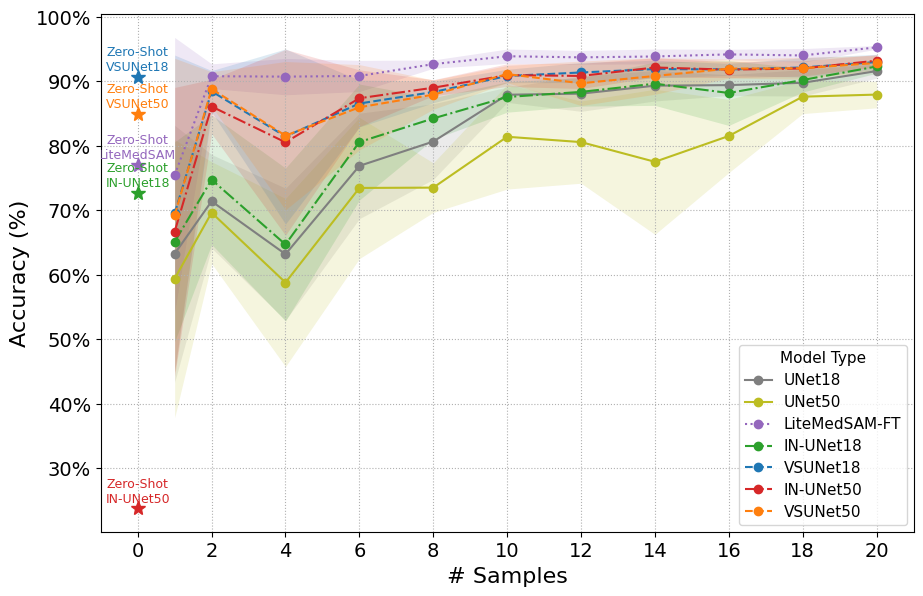

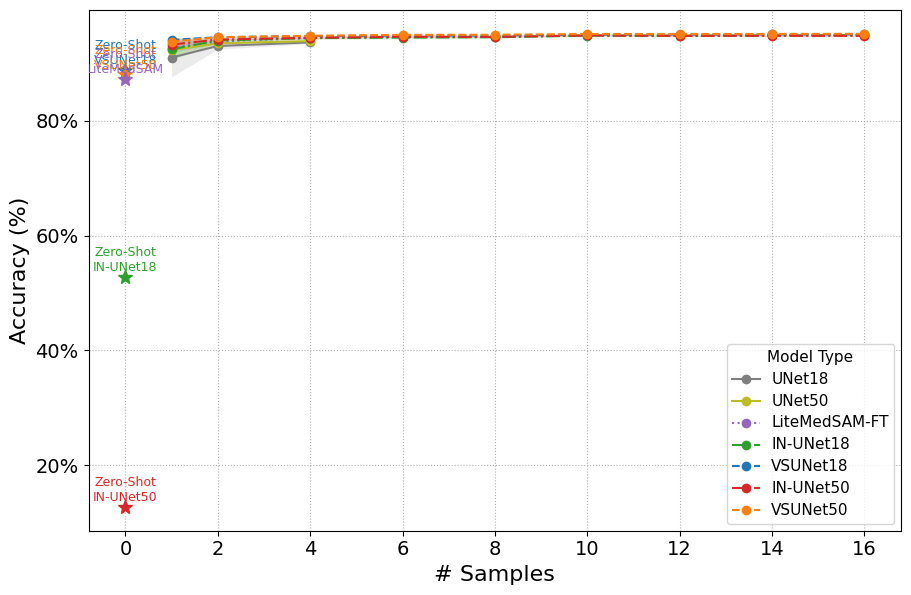

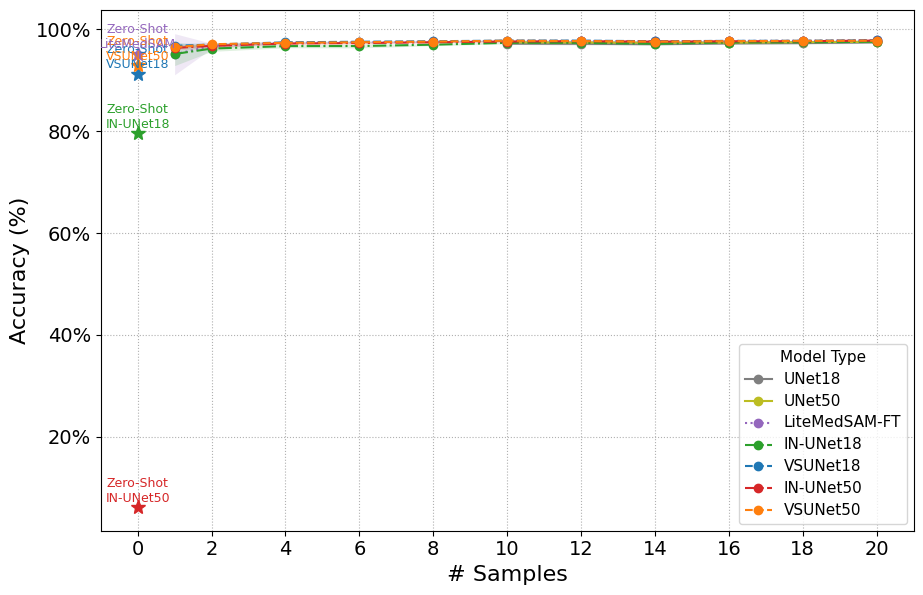

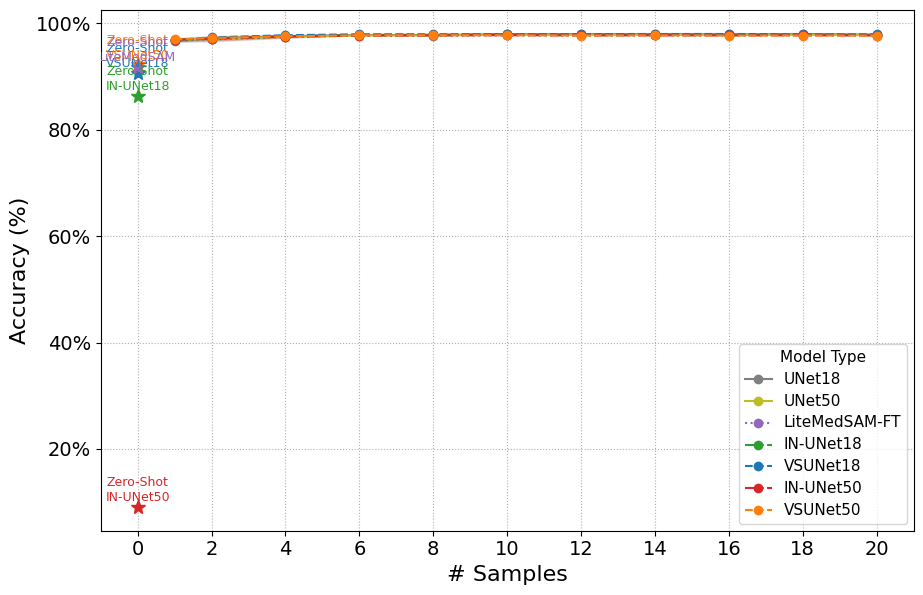

── Métrica: IoU ──


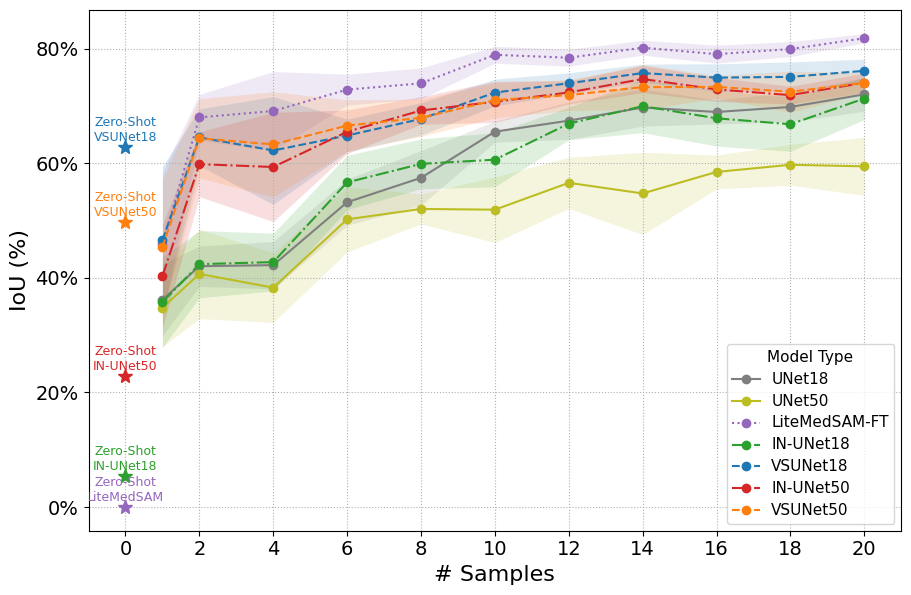

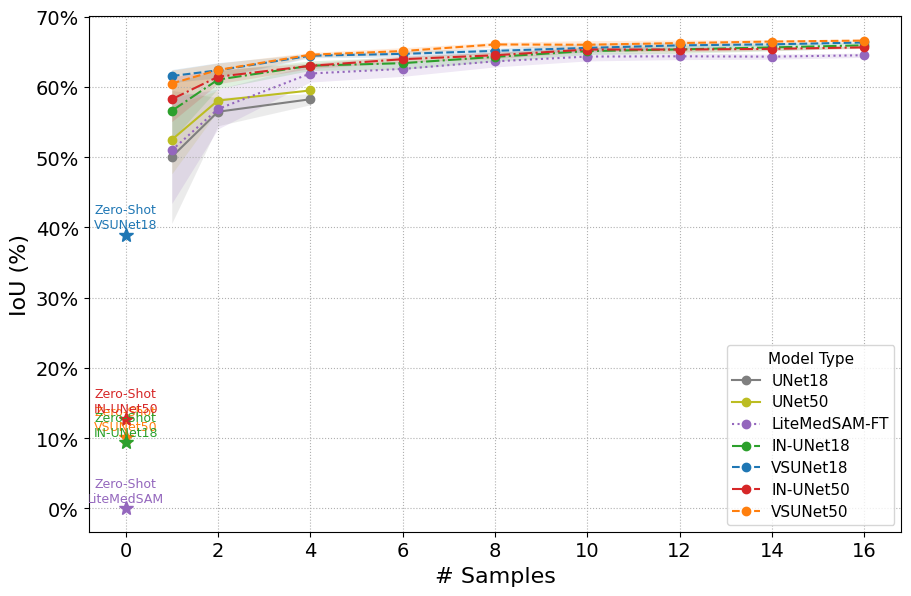

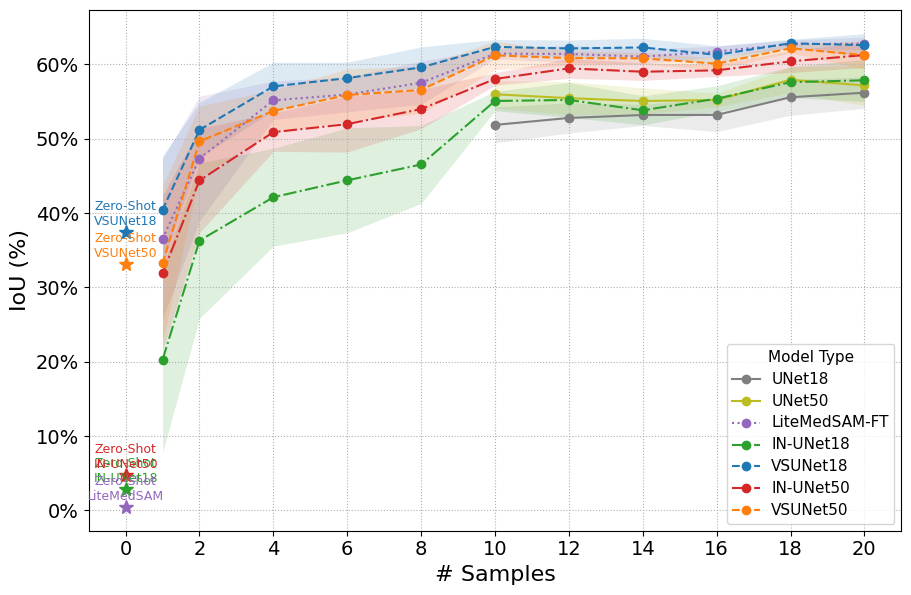

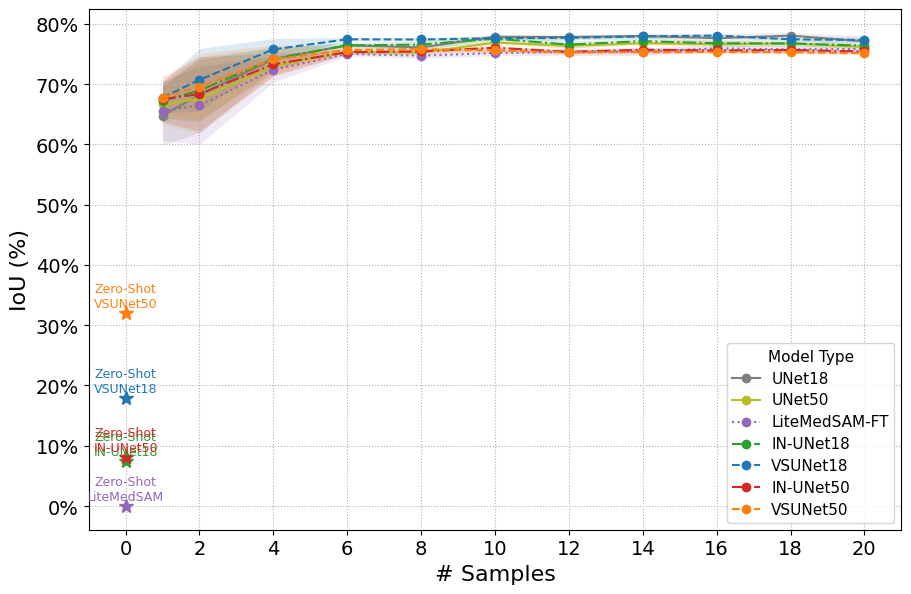

── Métrica: Precision ──


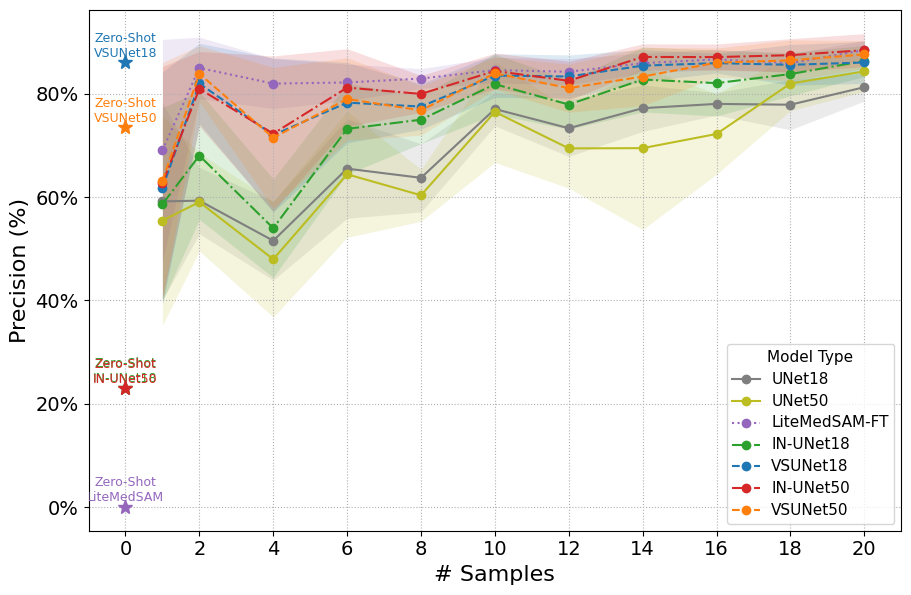

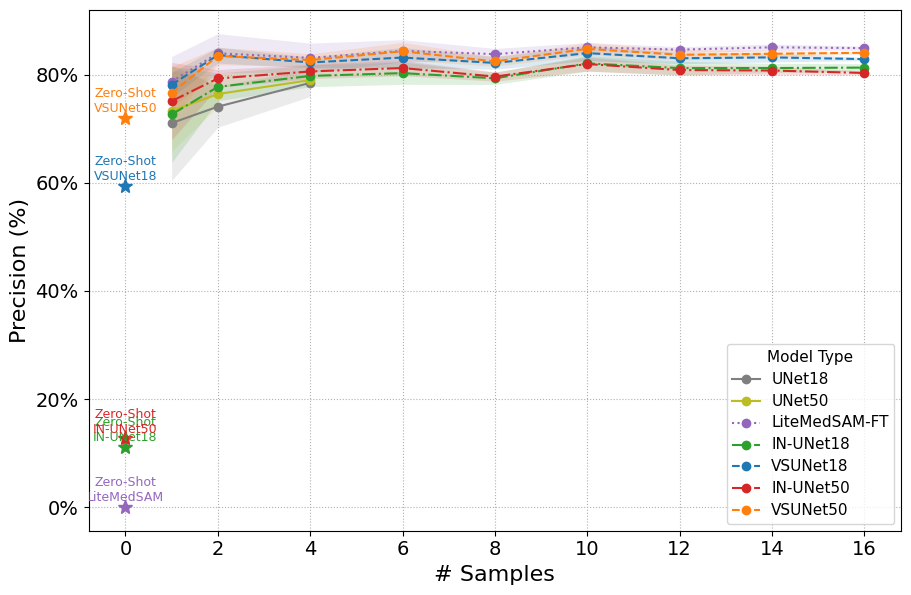

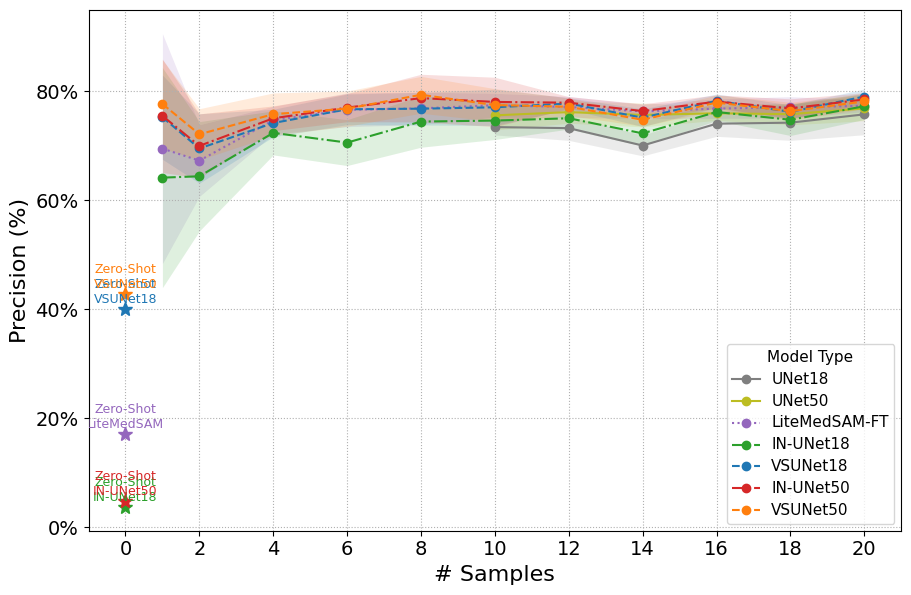

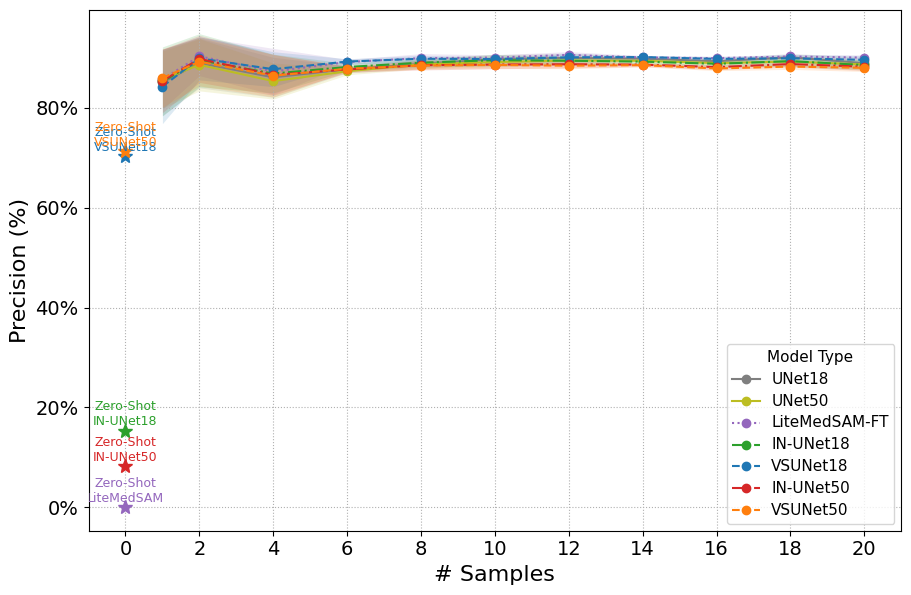

── Métrica: Recall ──


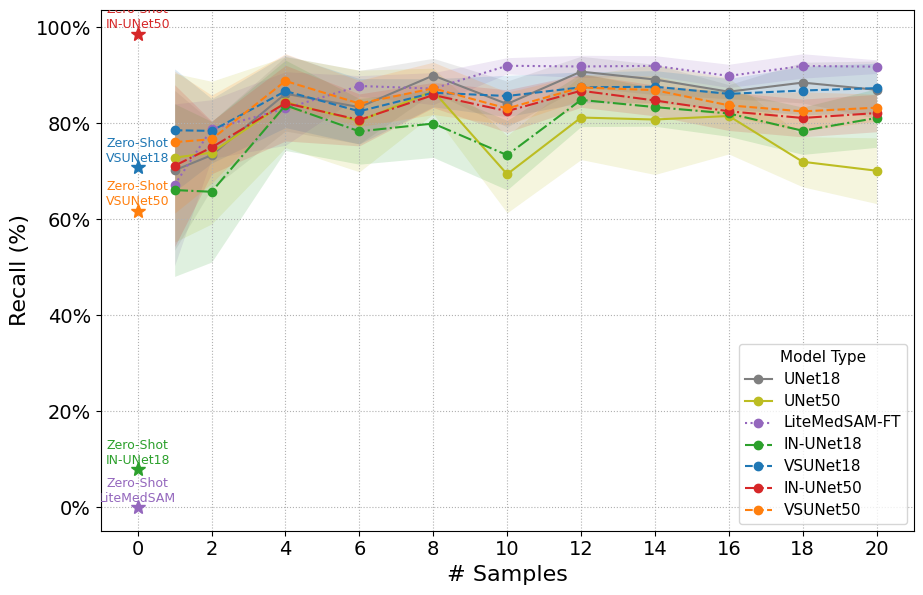

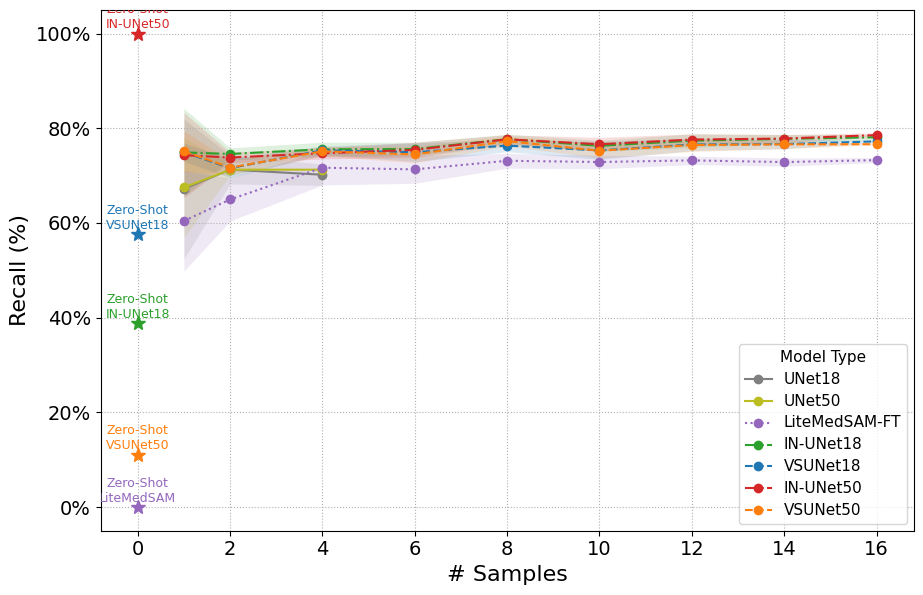

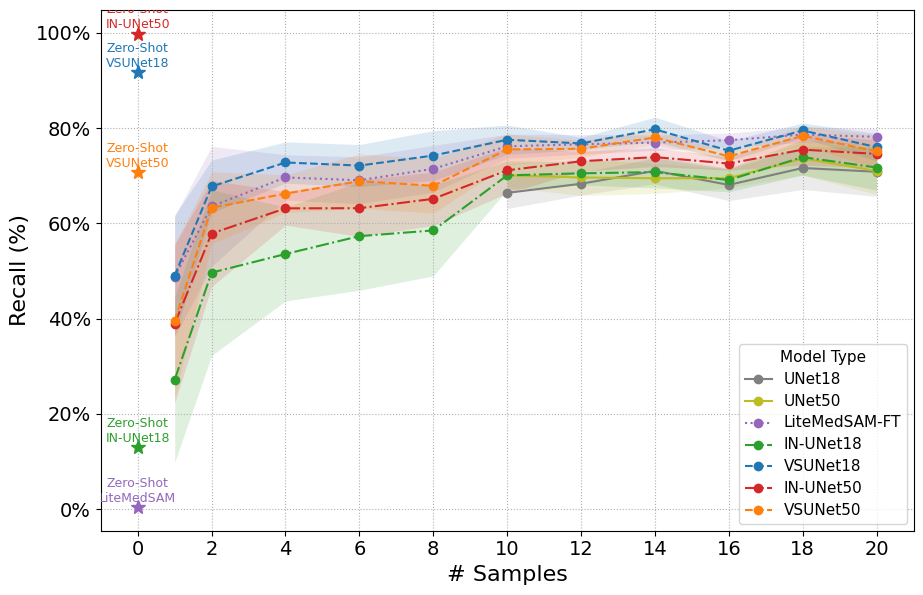

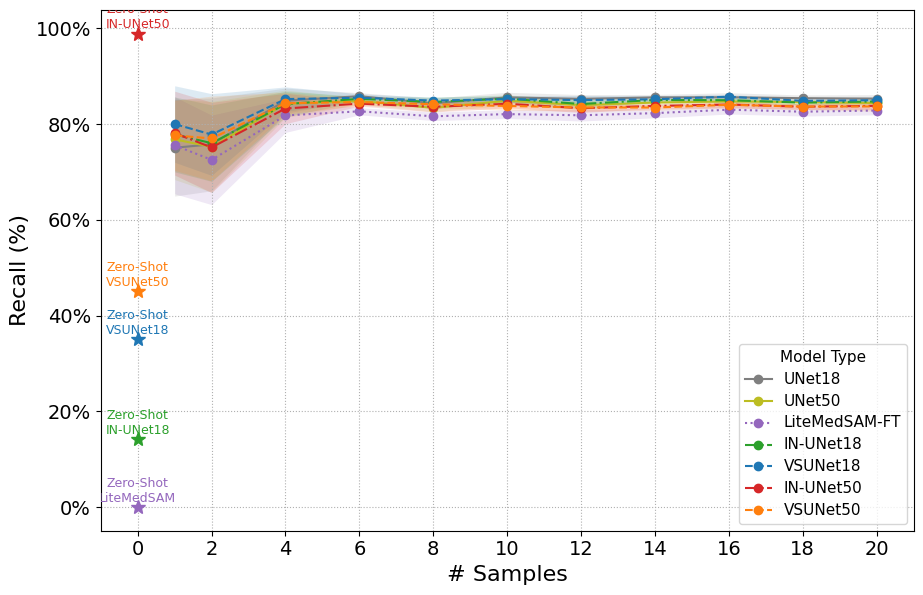

── Métrica: Dice ──


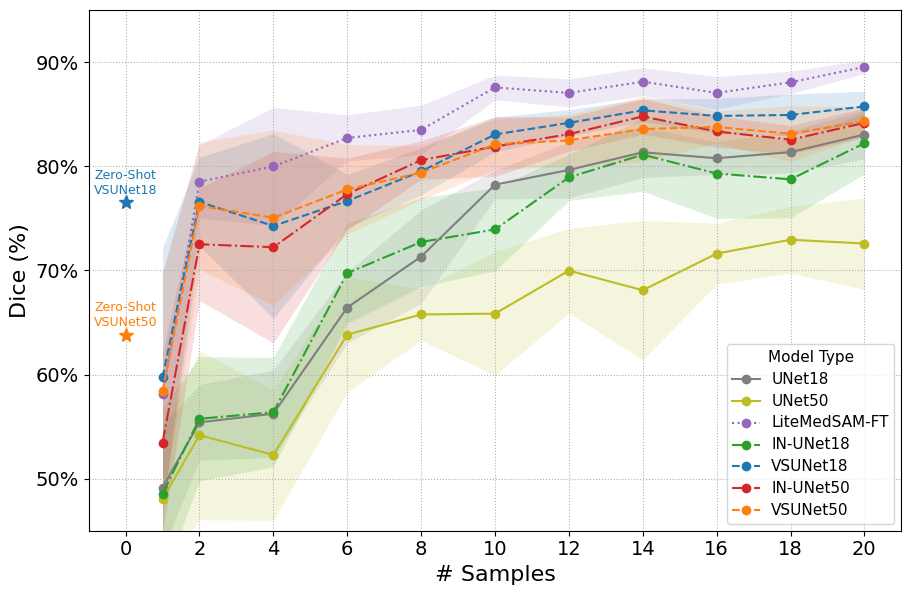

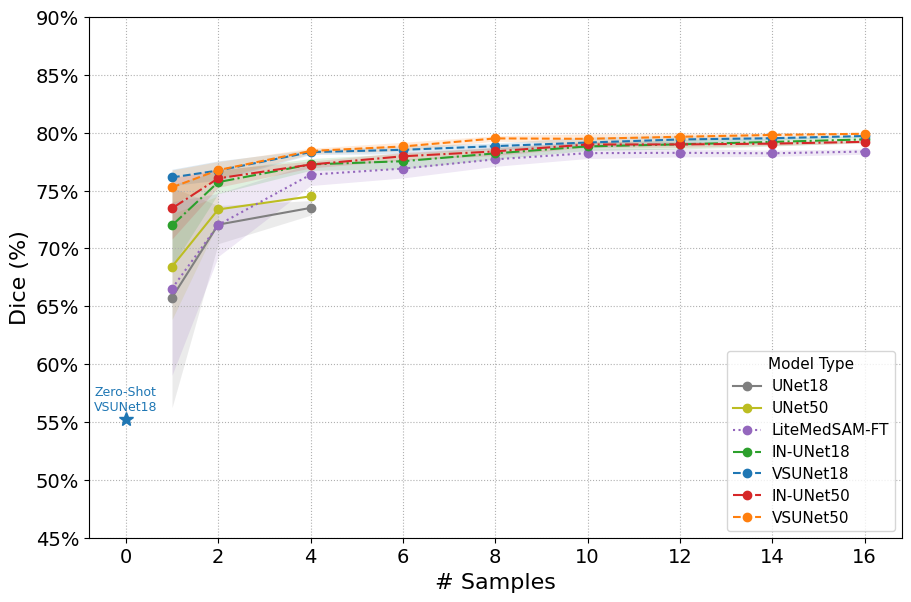

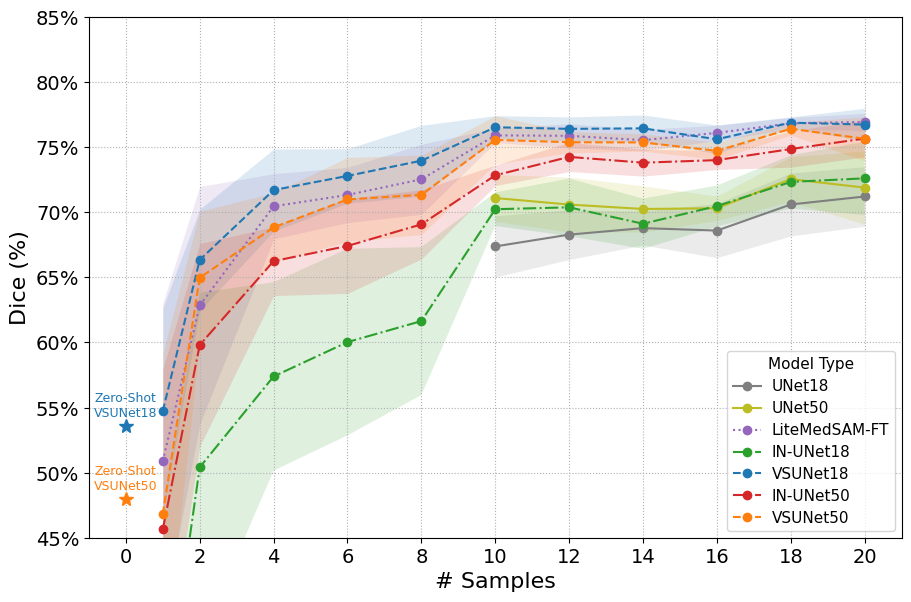

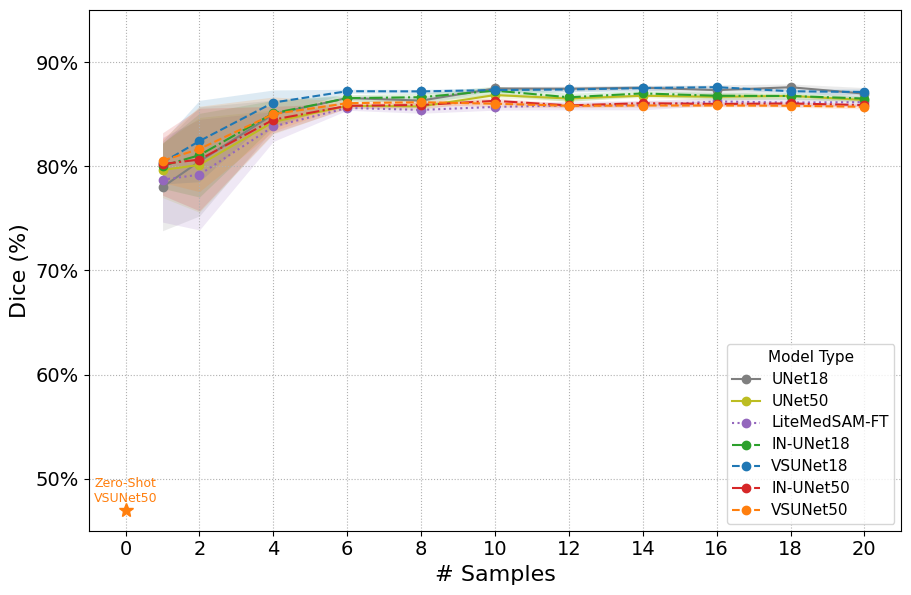

── Métrica: AUC ──


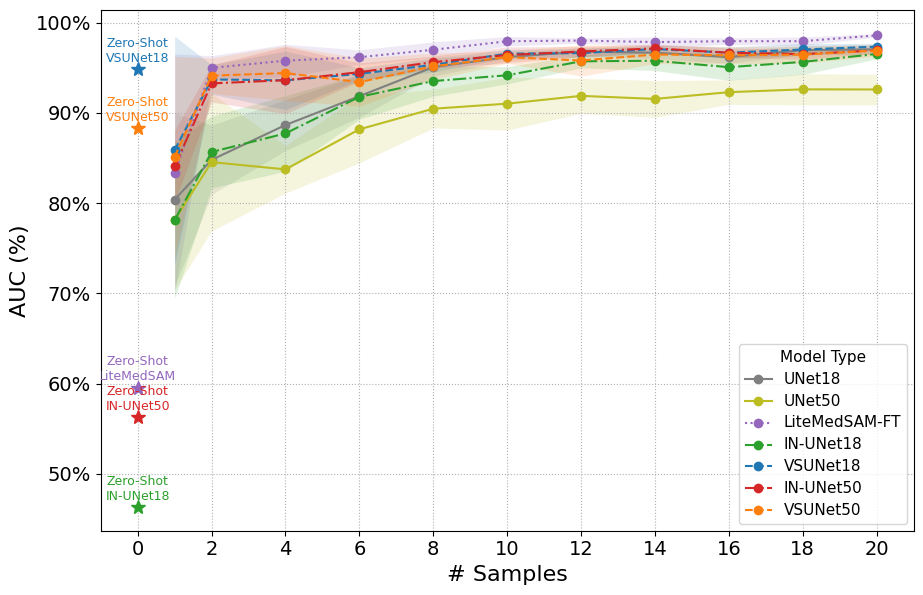

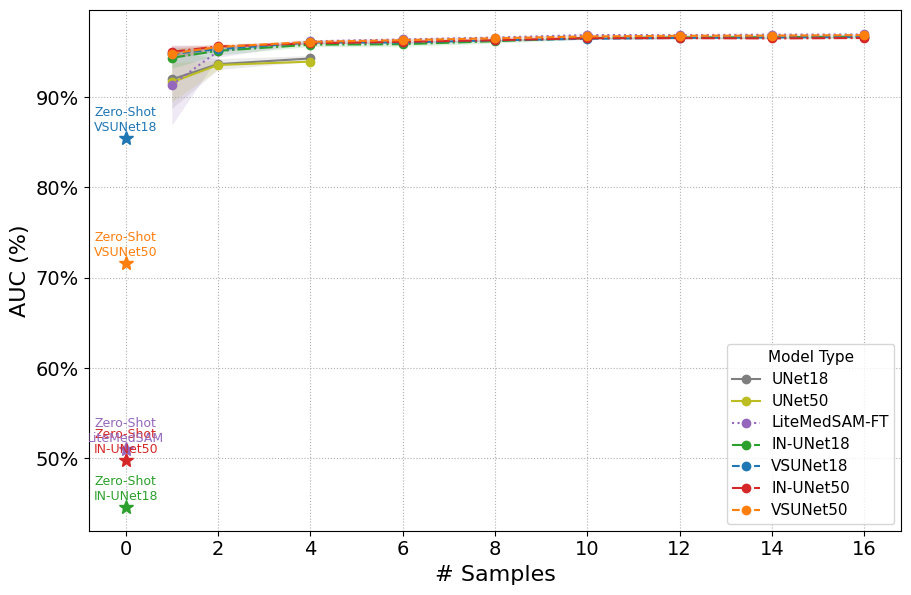

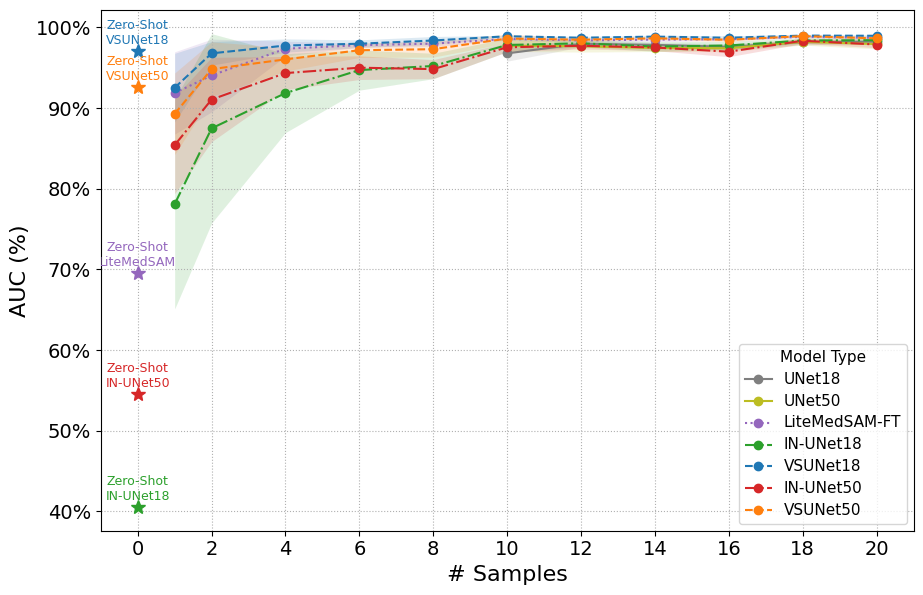

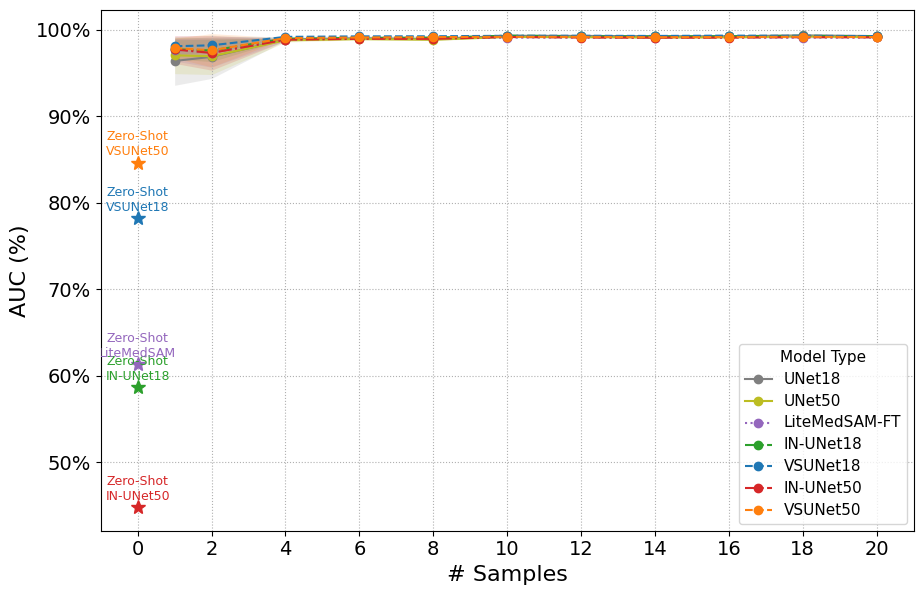

In [6]:
line_styles = default_line_styles_7way()

# Per-metric, per-dataset y_limits. None -> autoscale.
Y_LIMITS_BY_METRIC = {
    'Dice':      {'vessmap': (0.45, 0.95), 'drive': (0.45, 0.90), 'dca1': (0.45, 0.85), 'octa2d': (0.45, 0.95)},
    'IoU':       {ds: None for ds in PRETTY},
    'Accuracy':  {ds: None for ds in PRETTY},
    'Precision': {ds: None for ds in PRETTY},
    'Recall':    {ds: None for ds in PRETTY},
    'AUC':       {ds: None for ds in PRETTY},
}

FONT_SIZES = {
    'title': 16, 'xlabel': 16, 'ylabel': 16,
    'xaxis': 14, 'yaxis': 14,
    'legend': 11, 'zero_shot_annotation': 9, 'zero_shot_marker': 10,
}

for metric in METRICS:
    print(f'── Métrica: {metric} ──')
    for ds, df in frames.items():
        plot_mean_dice_score(
            df,
            dataset_name=PRETTY[ds],
            hue='model_type',
            x_data='num_samples',
            y_data=metric,
            line_styles=line_styles,
            color_map_override=PALETTE,
            annotate_zero_shot=True,
            title='',
            legend_title='Model Type',
            xlabel='# Samples',
            percentage=True,
            y_limits=(Y_LIMITS_BY_METRIC.get(metric) or {}).get(ds),
            save_path=os.path.join(FIGURES_DIR, f'cross_dataset_{ds}_{metric.lower()}.svg'),
            font_sizes=FONT_SIZES,
            figsize=(9, 6),
            legend_loc='lower right',
            share_zero_shot_color_with='finetuned',
        )

## 5. Top-line — melhor model_type em N=1 e em N máximo (por dataset)

In [21]:
top_rows = []
for ds, df in frames.items():
    if df.empty:
        continue
    df_ft = df[df['stage'] != 'zero_shot']
    if df_ft.empty:
        continue
    n_max = int(df_ft['num_samples'].max())
    for n in [1, n_max]:
        snap = (df_ft[df_ft['num_samples'] == n]
                .groupby('model_type')['Dice']
                .agg(['mean','std','count'])
                .reset_index()
                .sort_values('mean', ascending=False))
        if snap.empty:
            continue
        best = snap.iloc[0]
        top_rows.append({
            'dataset': ds,
            'num_samples': n,
            'best_model_type': best['model_type'],
            'mean_Dice': best['mean'],
            'std_Dice': best['std'],
            'n_runs': int(best['count']),
        })
topline = pd.DataFrame(top_rows)
topline.to_csv(os.path.join(RESULTS_DIR, 'cross_dataset_topline.csv'), index=False)
topline

,dataset,num_samples,best_model_type,mean_Dice,std_Dice,n_runs
0,vessmap,1,VSUNet18,0.597460,0.124416,15
1,vessmap,20,LiteMedSAM-FT,0.895343,0.006437,15
2,drive,1,VSUNet18,0.761387,0.007053,15
3,drive,16,VSUNet50,0.799093,0.000811,15
4,dca1,1,VSUNet18,0.547335,0.079107,15
5,dca1,20,LiteMedSAM-FT,0.769361,0.006627,15
6,octa2d,1,VSUNet50,0.805284,0.020924,15
7,octa2d,20,VSUNet18,0.871247,0.002918,15


In [23]:
# Per-image metrics (1 row per test image) used by §6 (bar significance markers) and §8 (Wilcoxon heatmaps).
# Loaded via the helper in utils_eval; the helpers below themselves live in utils_eval.
per_image = load_per_image_dict()

/home/wesleygalvao/Insync/wesleygalv@gmail.com/Google Drive - Shared with me/Mestrado - Visão Computacional/Pesquisa/Experimentos/fase_4/vess-shape-experiments/04_evaluation/utils_eval.py:735: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  return {ds: pd.read_csv(os.path.join(results_dir, f'{ds}_all_results_per_image.csv'))


## 6. Bar charts — Dice@N=1 cross-dataset (foco few-shot, todas as métricas)

Loop sobre as 6 métricas. Para cada métrica, gera 1 SVG com barras agrupadas
(datasets no eixo x, cores = modelos via `model_colors.yaml`). Os asteriscos sobre
as barras indicam significância Wilcoxon vs o par zero-shot correspondente.

── Métrica: Accuracy ──


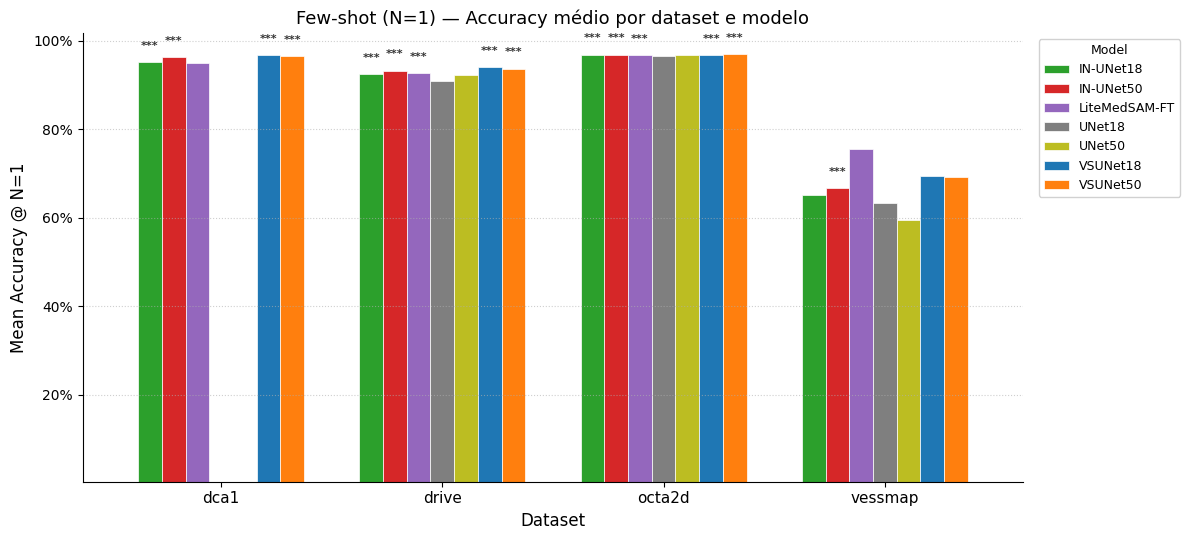

── Métrica: IoU ──


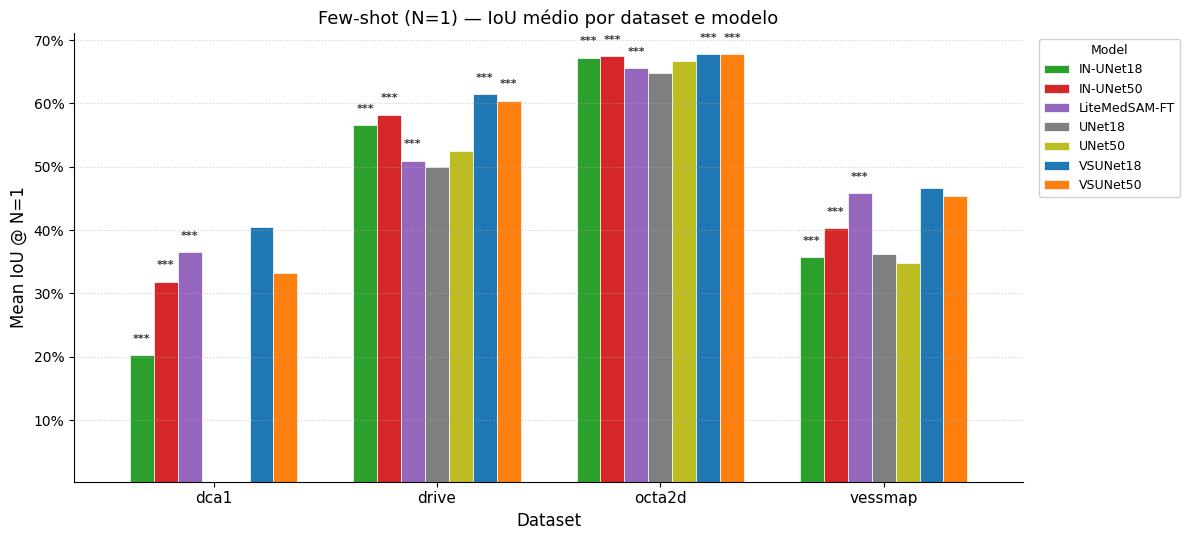

── Métrica: Precision ──


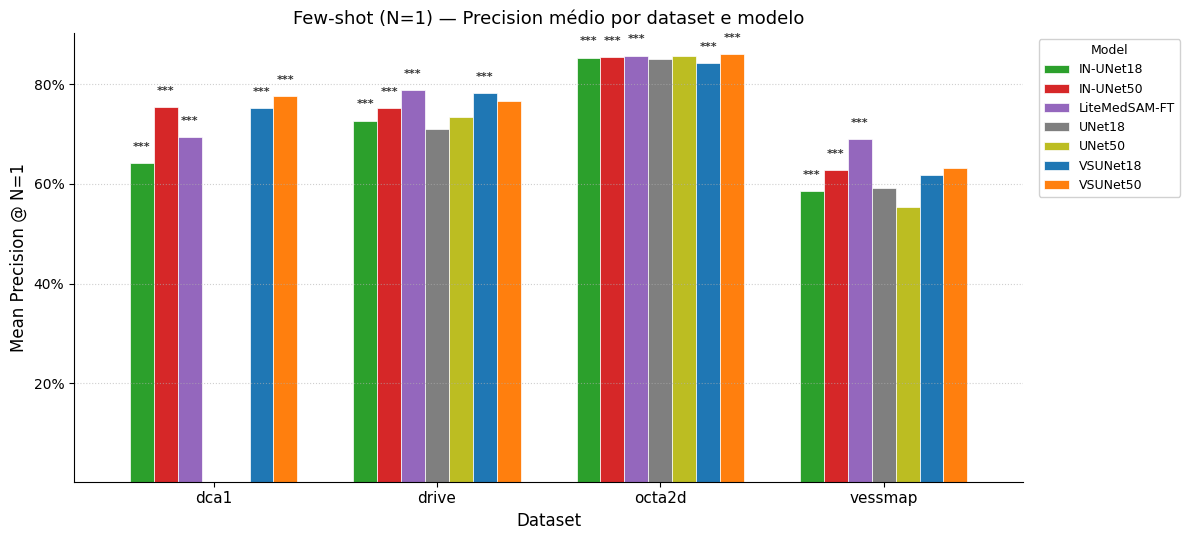

── Métrica: Recall ──


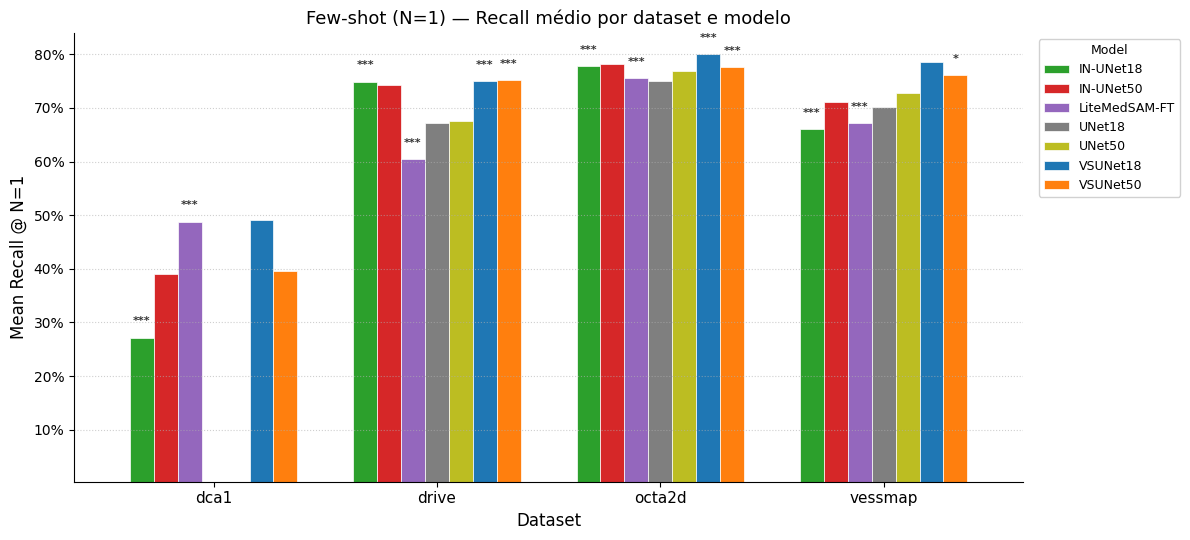

── Métrica: Dice ──


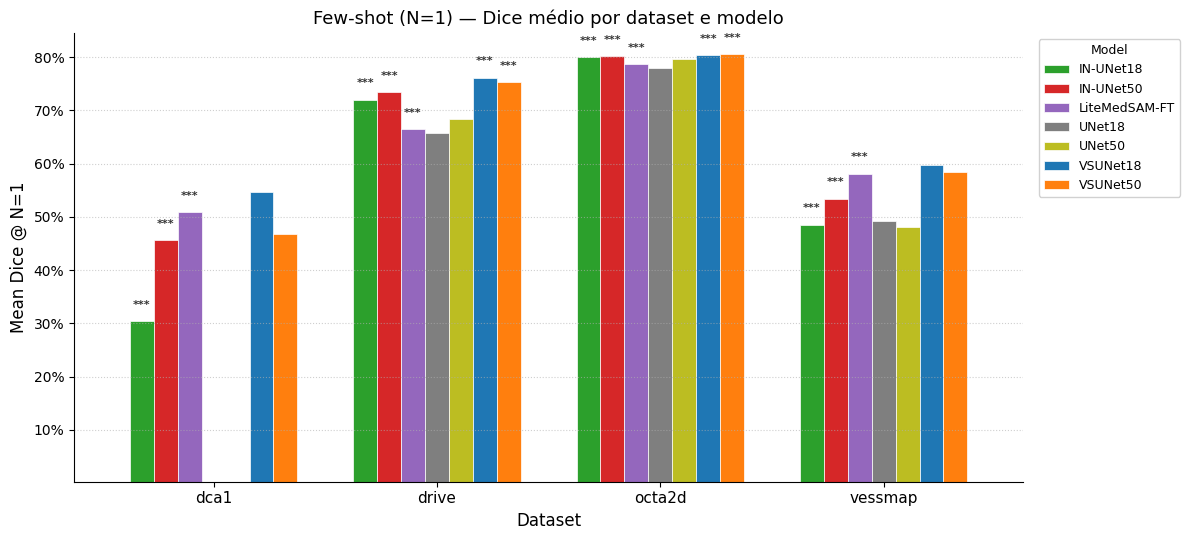

── Métrica: AUC ──


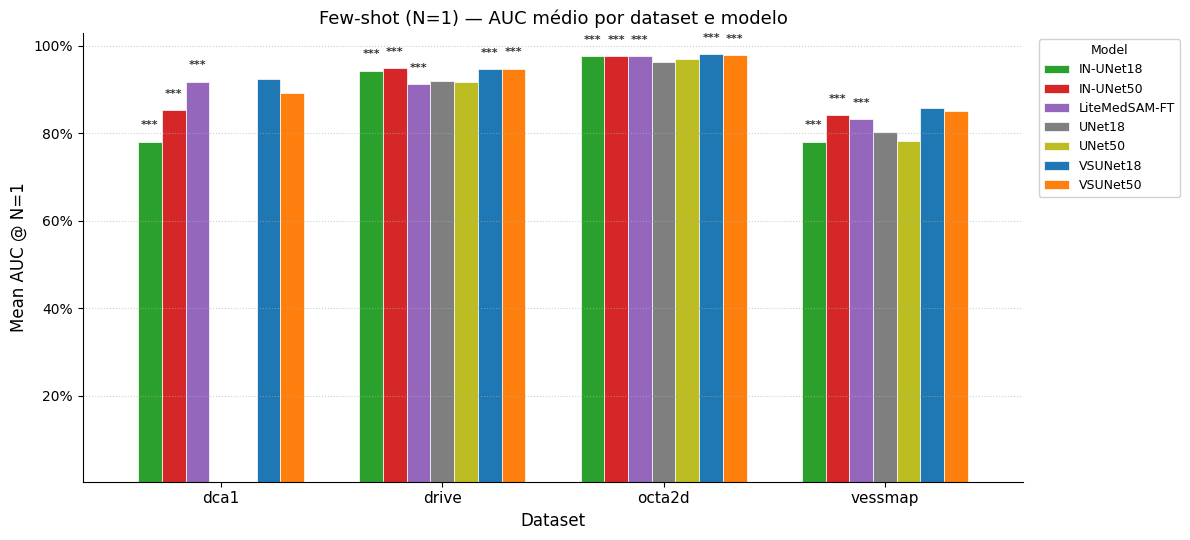

In [28]:
BAR_FONT_SIZES = {
    'title': 13, 'xlabel': 12, 'ylabel': 12,
    'xaxis': 11, 'yaxis': 10, 'legend': 9, 'sig_marker': 8,
}

for metric in METRICS:
    print(f'── Métrica: {metric} ──')
    n1 = (df_all[(df_all['num_samples'] == 1) & (df_all['stage'] != 'zero_shot')]
          .groupby(['dataset', 'model_type'])[metric]
          .mean()
          .reset_index())
    if n1.empty:
        print(f'  Sem dados para num_samples=1 ({metric}).')
        continue
    pivot = n1.pivot(index='model_type', columns='dataset', values=metric)
    sig_n1 = compute_bar_sig_pvalues(pivot, per_image, n_samples=1, metric=metric)
    plot_crossdataset_bar(
        pivot,
        title=f'Few-shot (N=1) — {metric} médio por dataset e modelo',
        ylabel=f'Mean {metric} @ N=1',
        save_path=os.path.join(FIGURES_DIR, f'cross_dataset_{metric.lower()}_at_n1.svg'),
        ymin=.28,
        sig_pvalues=sig_n1,
        color_map_override=PALETTE,
        percentage=True,
        font_sizes=BAR_FONT_SIZES
    
    )

## 7. Bar charts cross-dataset — zero-shot (N=0, todas as métricas)

Loop sobre as 6 métricas. Para cada uma, gera 1 SVG com barras agrupadas para
os modelos zero-shot reais (filtra `~is_mock`).

── Métrica: Accuracy ──


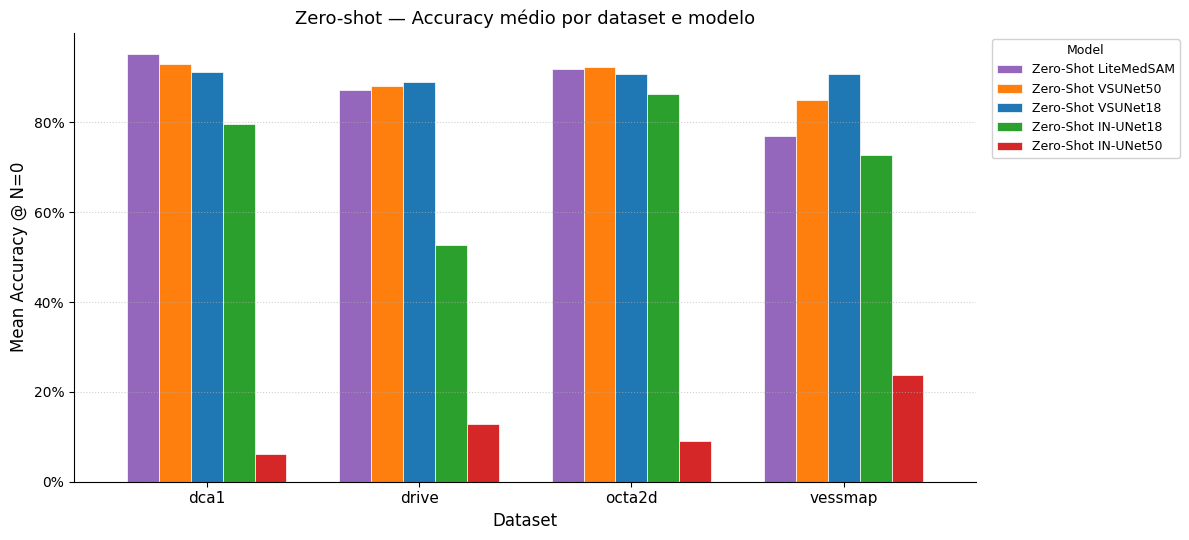

── Métrica: IoU ──


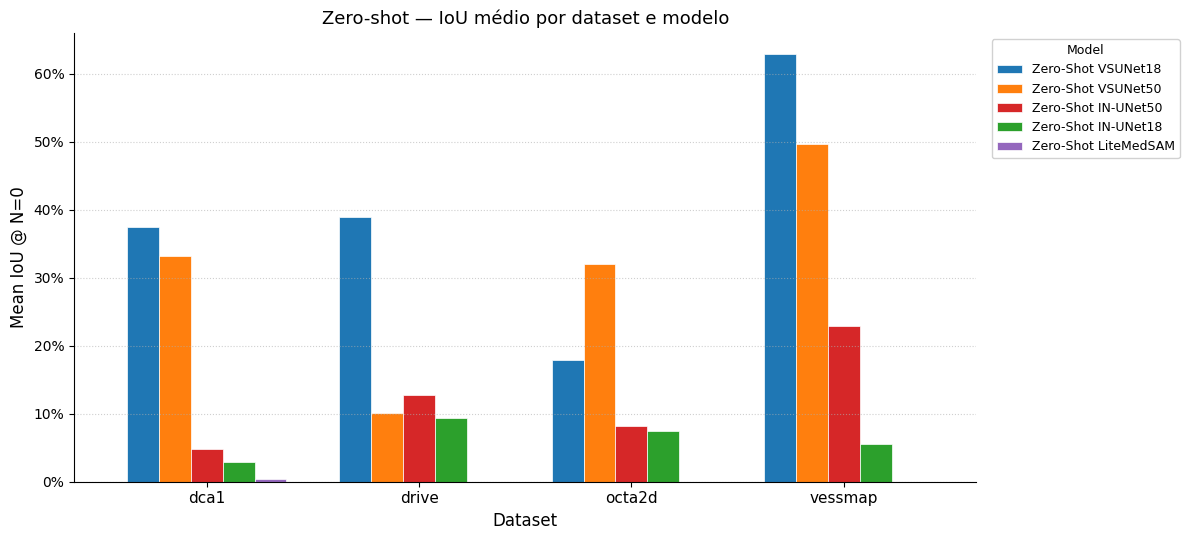

── Métrica: Precision ──


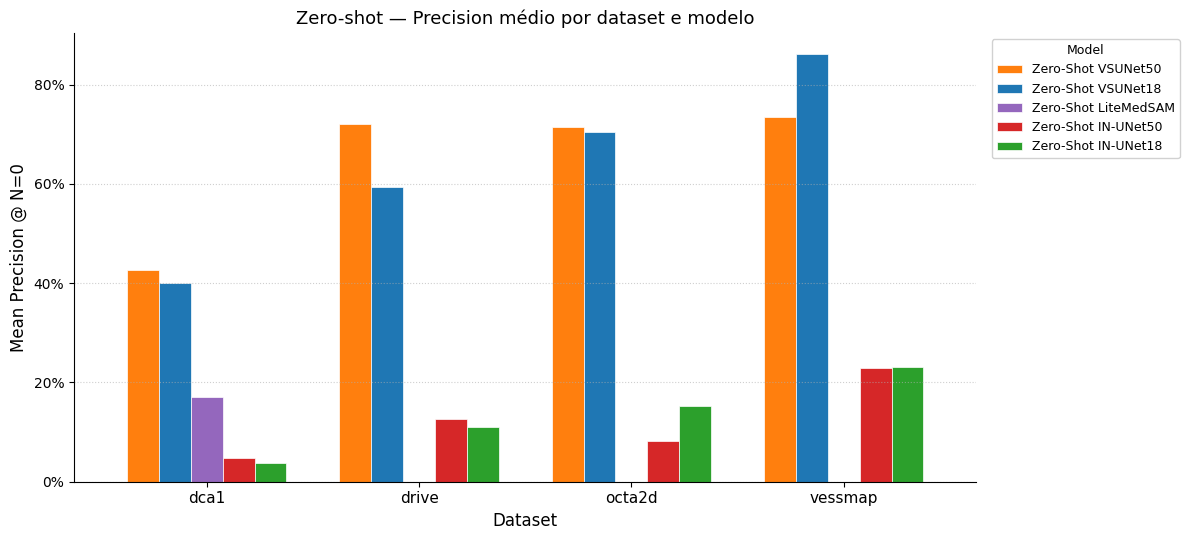

── Métrica: Recall ──


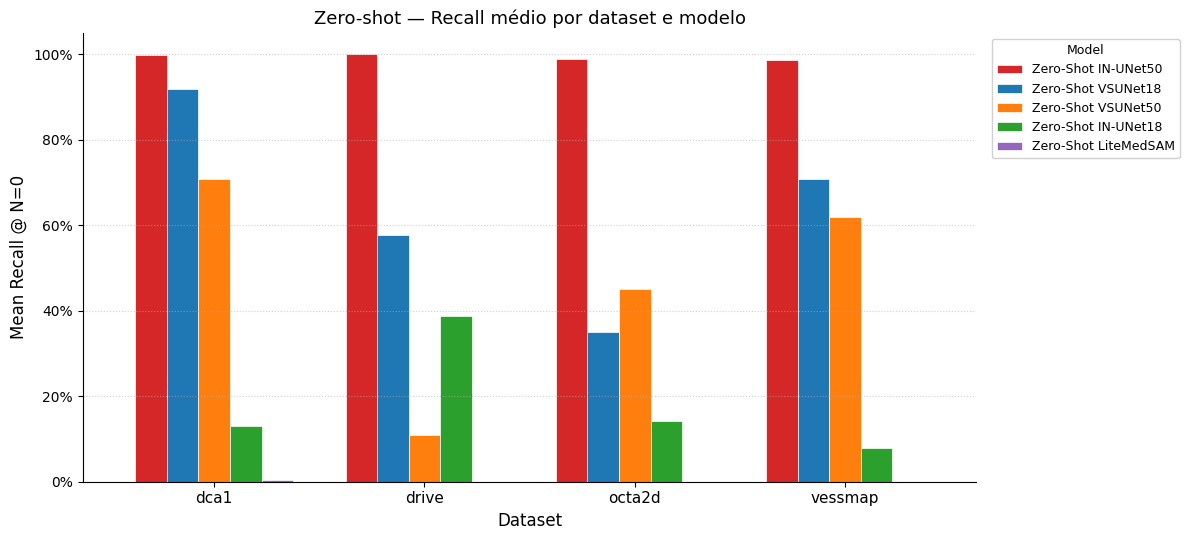

── Métrica: Dice ──


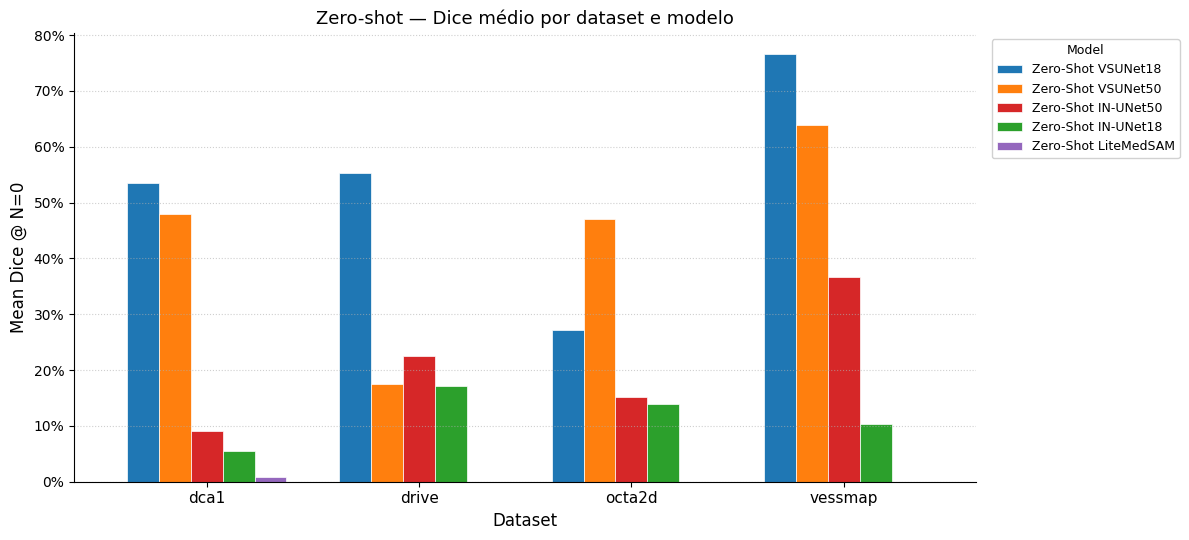

── Métrica: AUC ──


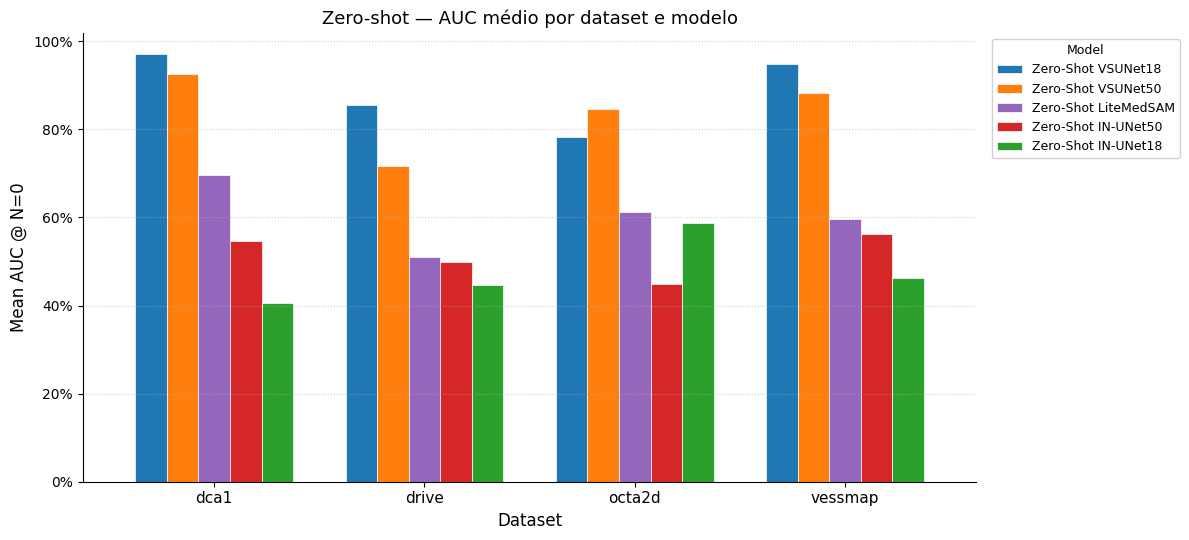

In [19]:
for metric in METRICS:
    print(f'── Métrica: {metric} ──')
    zs_real = (df_all[
        (df_all['num_samples'] == 0) &
        (df_all['stage'] == 'zero_shot') &
        (~df_all['is_mock'])
    ]
    .groupby(['dataset', 'model_type'])[metric]
    .mean()
    .reset_index())

    if zs_real.empty:
        print(f'  Sem dados zero-shot reais disponíveis ({metric}).')
        continue
    pivot_zs = zs_real.pivot(index='model_type', columns='dataset', values=metric)
    pivot_zs = pivot_zs.sort_values(pivot_zs.columns[0], ascending=False)
    plot_crossdataset_bar(
        pivot_zs,
        title=f'Zero-shot — {metric} médio por dataset e modelo',
        ylabel=f'Mean {metric} @ N=0',
        save_path=os.path.join(FIGURES_DIR, f'cross_dataset_{metric.lower()}_at_n0_zeroshot.svg'),
        ymin=0,
        color_map_override=PALETTE,
        percentage=True,
        font_sizes=BAR_FONT_SIZES,
    )

## 8. Validação Estatística — Wilcoxon signed-rank (VSUNet vs. pré-treinados alternativos, todas as métricas)

**Hipótese**: Métrica(VSUNet) > Métrica(IN-UNet ou LiteMedSAM-FT), por dataset × # samples.

Testamos se o pré-treino em VessShape (VSUNet) produz métricas **estatisticamente superiores**
às alternativas pré-treinadas em ImageNet (IN-UNet) e em MedSAM (LiteMedSAM-FT), tanto no
regime zero-shot (N=0) quanto no few-shot (N≥1). O teste é executado para **cada uma das 6
métricas**.

**Comparações realizadas (4 pares × 6 métricas = 24 SVGs):**
- VSUNet18 > IN-UNet18 · VSUNet18 > LiteMedSAM-FT
- VSUNet50 > IN-UNet50 · VSUNet50 > LiteMedSAM-FT

**Metodologia:**
- **Dados**: métricas por imagem (`{ds}_all_results_per_image.csv`). Múltiplas repetições para o
  mesmo N são agregadas por média da métrica por imagem antes do teste (evita pseudoreplicação).
- **N=0**: usa modelos zero-shot (`Zero-Shot VSUNet*`, `Zero-Shot IN-UNet*`, `Zero-Shot LiteMedSAM`).
  Células NaN (×) indicam que o zero-shot real não está disponível para aquele dataset.
- **Teste**: Wilcoxon signed-rank unilateral (H₁: A > B), pareado por imagem. Requer ≥ 5 imagens
  comuns. Limiar α = 0,05.
- **Cores**: azul escuro = significativo; azul claro = não significativo; cinza + × = sem dados.

── Métrica: Accuracy ──


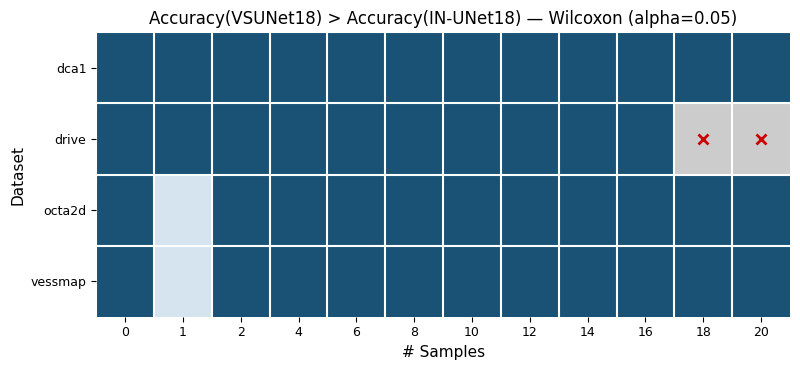

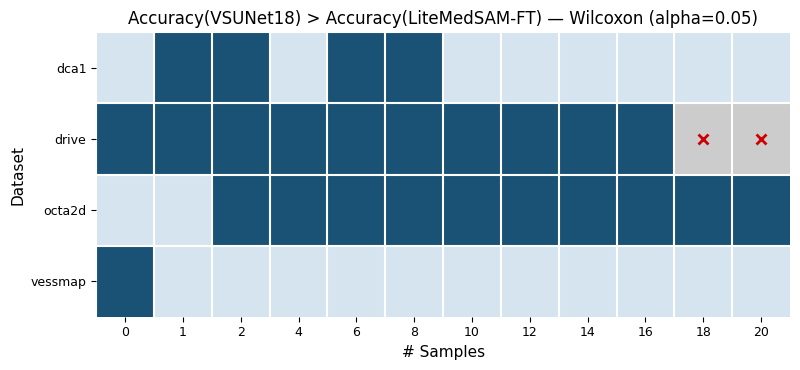

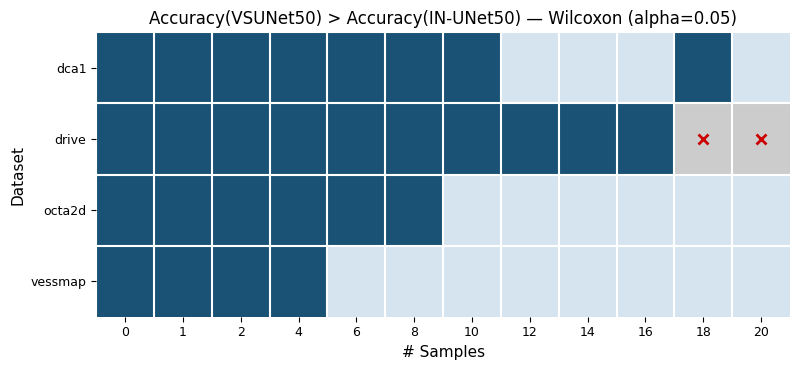

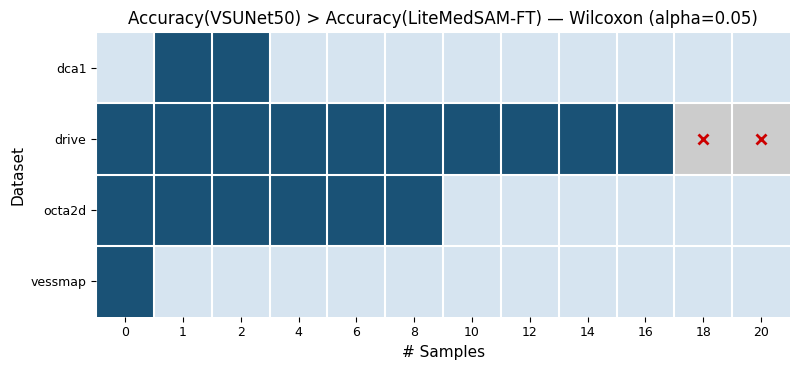

── Métrica: IoU ──


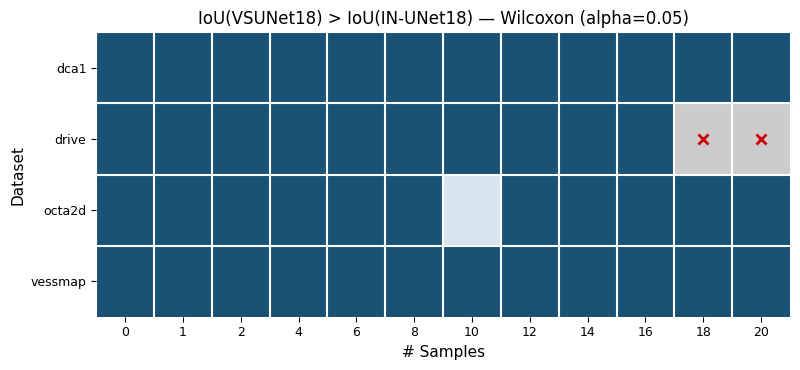

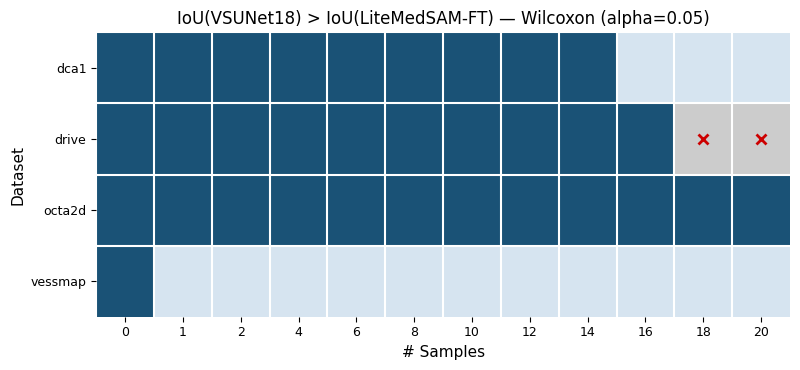

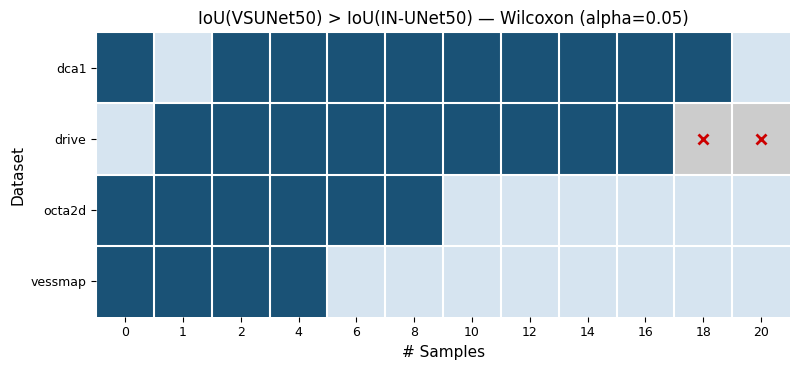

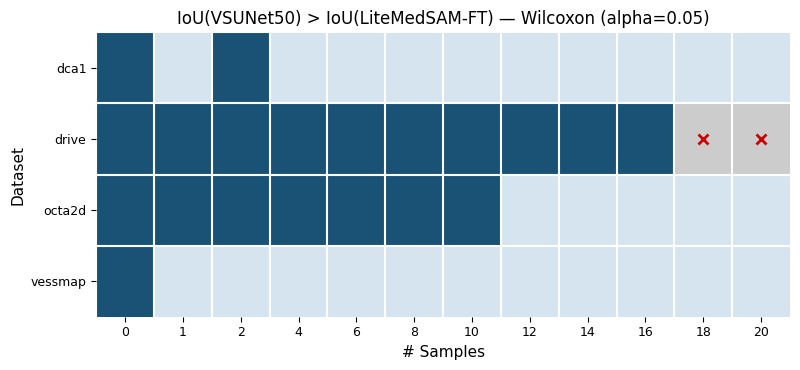

── Métrica: Precision ──


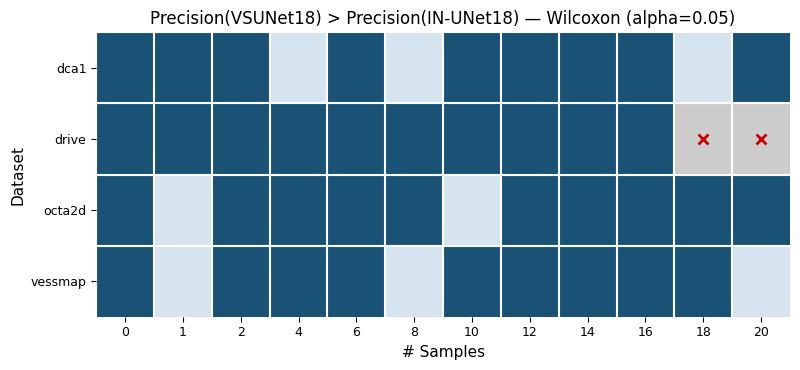

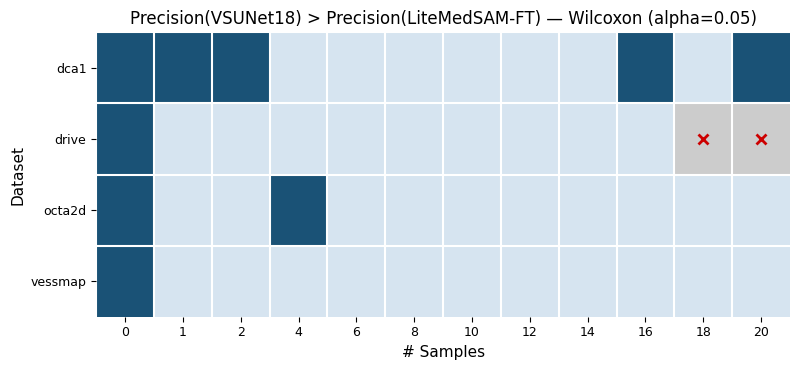

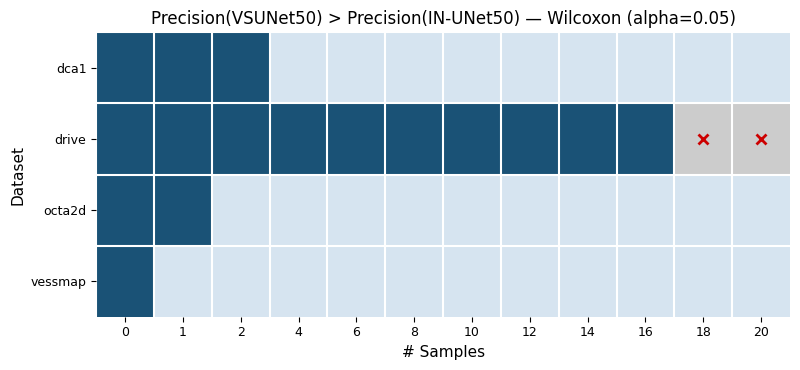

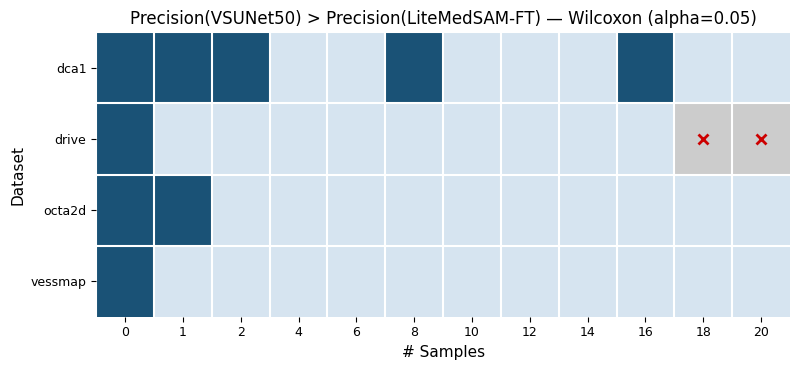

── Métrica: Recall ──


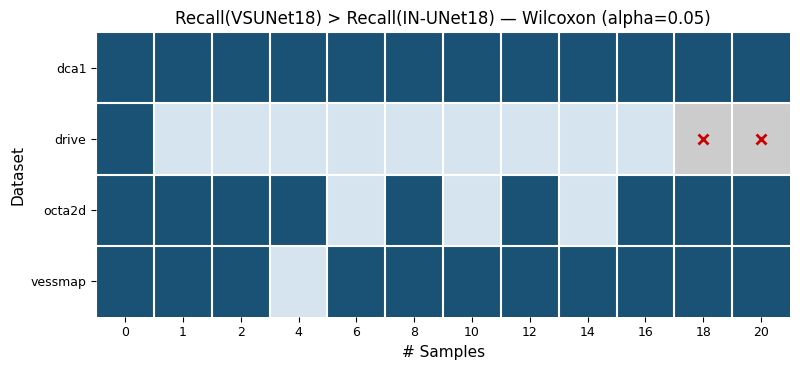

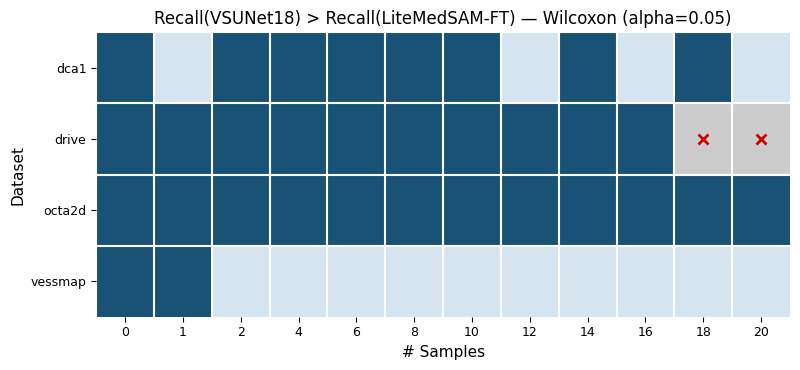

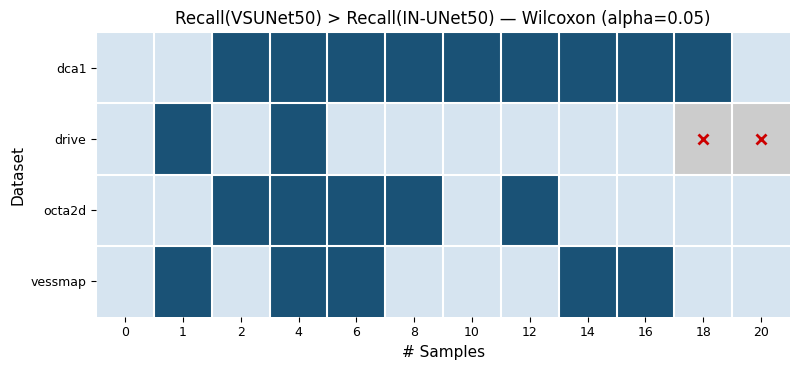

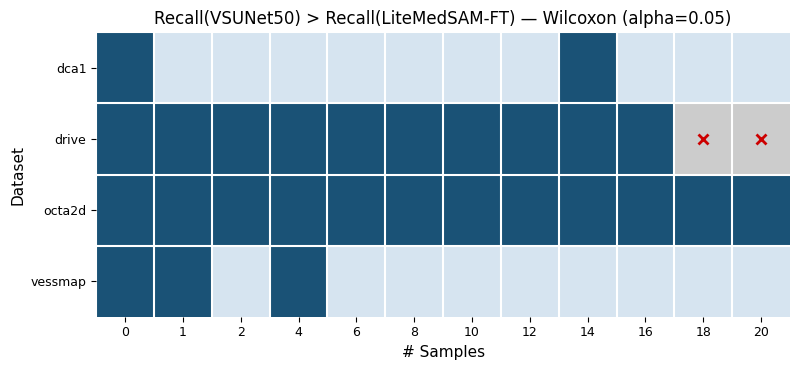

── Métrica: Dice ──


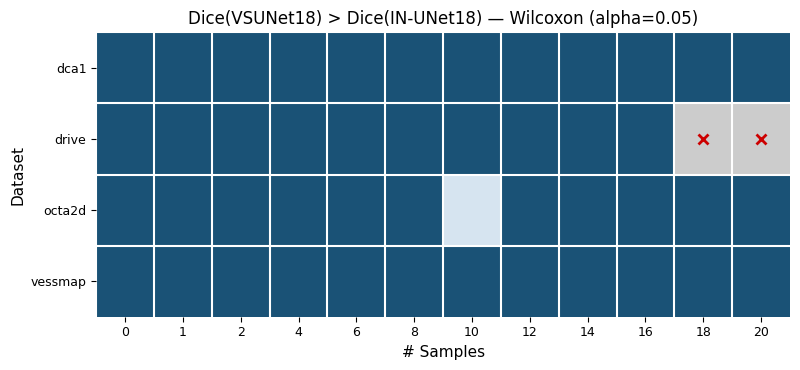

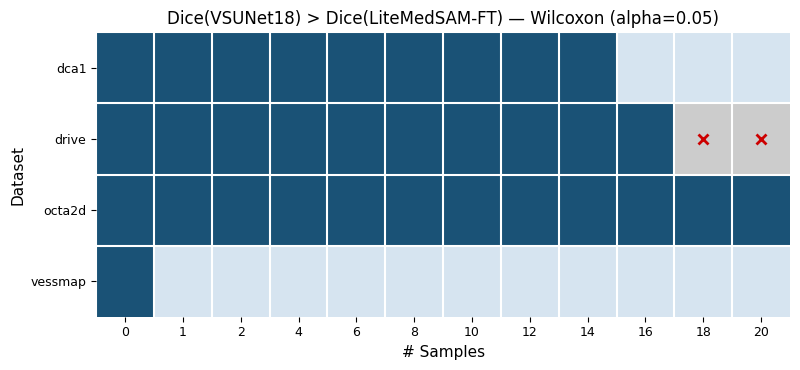

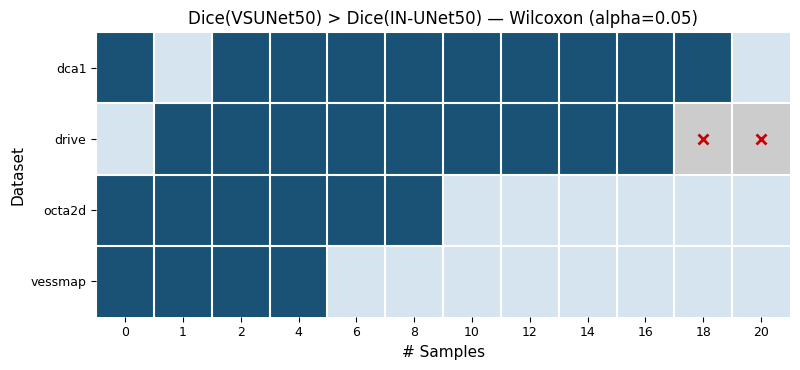

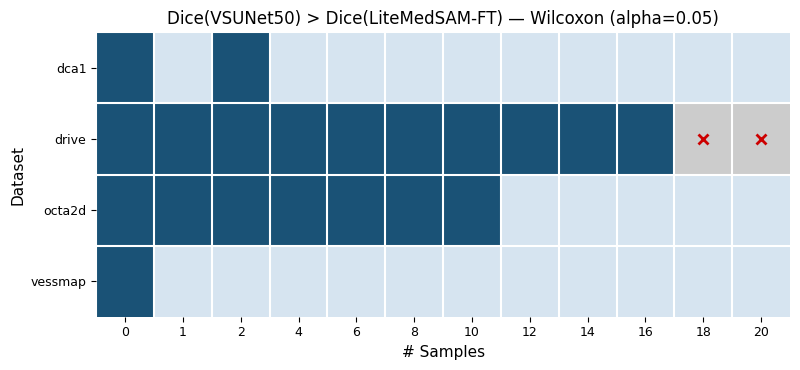

── Métrica: AUC ──


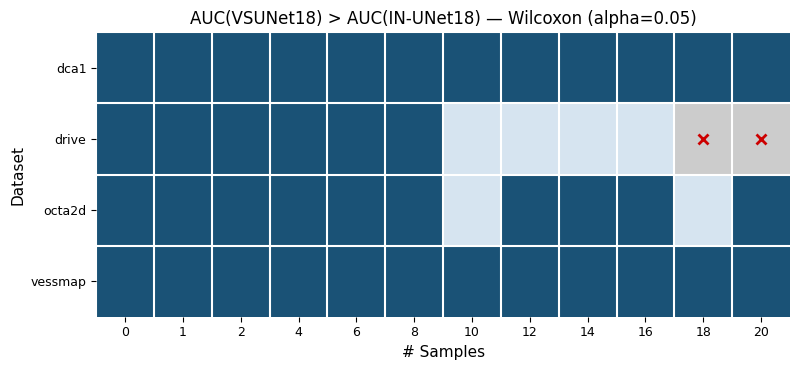

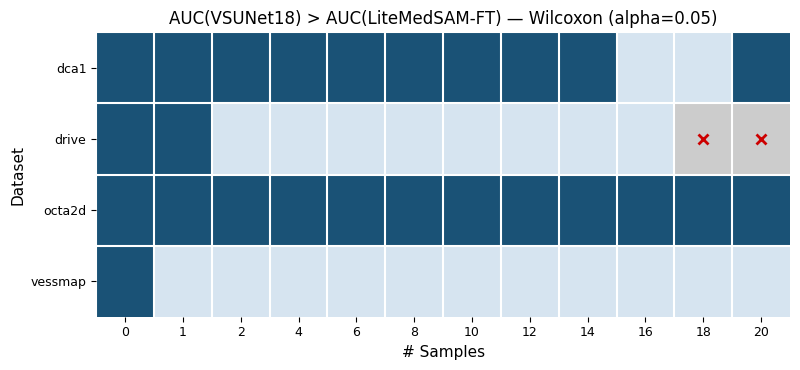

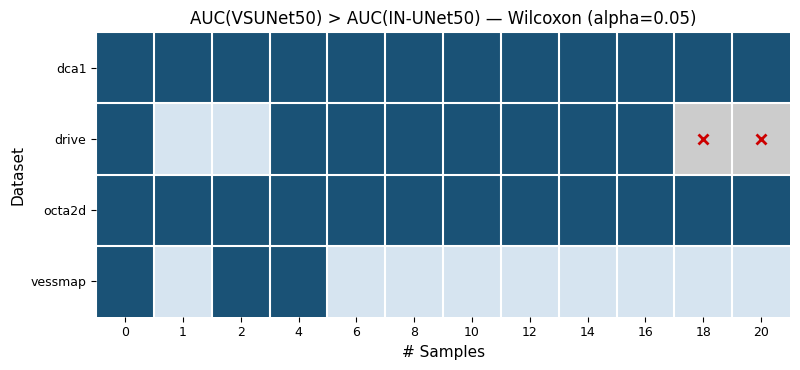

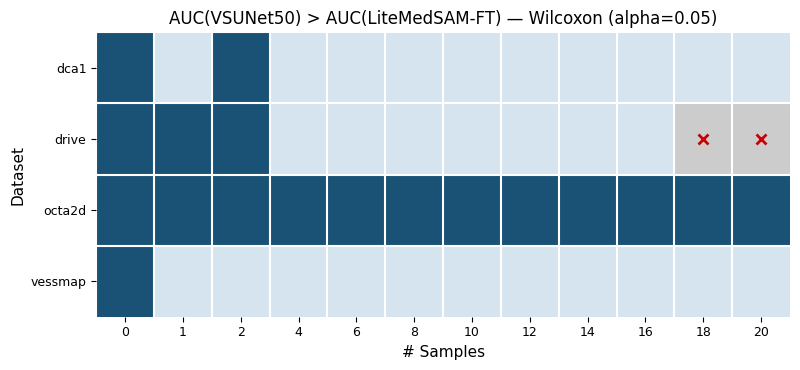

In [20]:
HEATMAP_FONT_SIZES = {
    'title': 12, 'xlabel': 11, 'ylabel': 11, 'xaxis': 9, 'yaxis': 9,
}

# 4 comparisons × 6 metrics = 24 SVGs. Each cell = (dataset, N) Wilcoxon outcome.
# compute_pairwise_sig_matrix + plot_sig_heatmap moved to utils_eval; this cell
# only orchestrates the loop.
for metric in METRICS:
    print(f'── Métrica: {metric} ──')
    for model_a, model_b in VSUPAIR_COMPARISONS:
        p_mat = compute_pairwise_sig_matrix(model_a, model_b, per_image, metric=metric)
        fname = (
            f"sig_wilcoxon_{model_a}_vs_{model_b}_{metric.lower()}.svg".replace('-', '_')
        )
        plot_sig_heatmap(
            p_mat,
            title=f'{metric}({model_a}) > {metric}({model_b}) — Wilcoxon (alpha={ALPHA})',
            save_path=os.path.join(FIGURES_DIR, fname),
            font_sizes=HEATMAP_FONT_SIZES,
        )